# Notebook B — RF filtering experiments

## Cell 1 — Step 0: Configuration

In [1]:
# Step 0 — RF filtering experiment configuration

from pathlib import Path
import json
import random
import time
import shutil
import joblib

from dataclasses import dataclass
from typing import Union, Tuple, Dict, Sequence, Optional, List, Any

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# ---- Phase switch ----
PHASE = "small"   # "small" or "full"

seed = 42
num_classes = 3
label_values = [0, 1, 2]
nodata_value = -9999
ignore_index = -9999

in_channels = 6
bands = ["R", "G", "B", "NIR", "SWIR1", "SWIR2"]
normalisation = "per_band_mean_std"

CONFIGS = {
    "small": {
        "img_path": "../../data/inputs/map/map_test.tif",
        "lbl_path": "../../data/inputs/label/label_test.tif",
        "patch_size": 256,
        "stride_train": 256,
        "block_size": 2048,
        "split_dir": "../../data/outputs/proposed/small_rf_p256_b2048",

        # same RF table extraction design as Notebook A
        "max_train_pixels_total": 120000,
        "max_val_pixels_total": 40000,
        "max_test_pixels_total": 40000,
        "max_pixels_per_patch": 2048,
    },
    "full": {
        "img_path": "../../data/inputs/map/map.tif",
        "lbl_path": "../../data/inputs/label/para_three_class.tif",
        "patch_size": 256,
        "stride_train": 256,
        "block_size": 2048,
        "split_dir": "../../data/outputs/proposed/full_rf_p256_b2048",

        "max_train_pixels_total": 300000,
        "max_val_pixels_total": 80000,
        "max_test_pixels_total": 80000,
        "max_pixels_per_patch": 2048,
    },
}

assert PHASE in CONFIGS

cfg = CONFIGS[PHASE].copy()
cfg.update({
    "phase": PHASE,
    "seed": seed,
    "num_classes": num_classes,
    "label_values": label_values,
    "nodata_value": nodata_value,
    "ignore_index": ignore_index,
    "in_channels": in_channels,
    "bands": bands,
    "normalisation": normalisation,
})

split_dir = Path(cfg["split_dir"])
split_dir.mkdir(parents=True, exist_ok=True)

print("=== Active RF filtering configuration ===")
for k in [
    "phase", "img_path", "lbl_path", "patch_size", "stride_train",
    "block_size", "split_dir", "max_train_pixels_total",
    "max_val_pixels_total", "max_test_pixels_total", "max_pixels_per_patch"
]:
    print(f"{k:24s}: {cfg[k]}")

=== Active RF filtering configuration ===
phase                   : small
img_path                : ../../data/inputs/map/map_test.tif
lbl_path                : ../../data/inputs/label/label_test.tif
patch_size              : 256
stride_train            : 256
block_size              : 2048
split_dir               : ../../data/outputs/proposed/small_rf_p256_b2048
max_train_pixels_total  : 120000
max_val_pixels_total    : 40000
max_test_pixels_total   : 40000
max_pixels_per_patch    : 2048


## Cell 2 — Step 1.1: PatchSpec and split utilities

In [2]:
# Step 1.1 — PatchSpec and split utilities

@dataclass(frozen=True)
class PatchSpec:
    row_off: int
    col_off: int
    height: int
    width: int

def load_patch_specs(csv_path: Path) -> List[PatchSpec]:
    df = pd.read_csv(csv_path)
    return [
        PatchSpec(int(r.row_off), int(r.col_off), int(r.height), int(r.width))
        for r in df.itertuples(index=False)
    ]

def keys_from_patches(patches: Sequence[PatchSpec]):
    return set((p.row_off, p.col_off, p.height, p.width) for p in patches)

def integrity_check_no_duplicates(train_patches, val_patches, test_patches):
    kt = keys_from_patches(train_patches)
    kv = keys_from_patches(val_patches)
    ks = keys_from_patches(test_patches)

    inter_tv = len(kt & kv)
    inter_ts = len(kt & ks)
    inter_vs = len(kv & ks)

    print("Duplicate patch keys across splits (should all be 0):")
    print("Train ∩ Val :", inter_tv)
    print("Train ∩ Test:", inter_ts)
    print("Val ∩ Test  :", inter_vs)

    assert inter_tv == 0 and inter_ts == 0 and inter_vs == 0, "Overlap detected across splits!"

print("Split utilities ready.")

Split utilities ready.


## Cell 3 — Step 1.2: Load splits and train stats

In [3]:
# Step 1.2 — Load splits and train-only mean/std from Notebook A artefacts

train_patches = load_patch_specs(split_dir / "train_patches.csv")
val_patches   = load_patch_specs(split_dir / "val_patches.csv")
test_patches  = load_patch_specs(split_dir / "test_patches.csv")

train_mean = np.load(split_dir / "train_mean.npy")
train_std  = np.load(split_dir / "train_std.npy")

img_path = cfg["img_path"]
lbl_path = cfg["lbl_path"]

print("Train/Val/Test patches:", len(train_patches), len(val_patches), len(test_patches))
print("train_mean shape:", train_mean.shape)
print("train_std shape :", train_std.shape)

integrity_check_no_duplicates(train_patches, val_patches, test_patches)

Train/Val/Test patches: 2012 432 520
train_mean shape: (6,)
train_std shape : (6,)
Duplicate patch keys across splits (should all be 0):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


## Cell 4 — Step 1.3: Load tuned RF settings and patch scores

In [4]:
# Step 1.3 — Load tuned RF model, params, and patch scores from Notebook A

rf_model_path = split_dir / "rf_model_tuned.joblib"
rf_params_path = split_dir / "rf_model_tuned_params.json"
rf_eval_path = split_dir / "rf_tuned_eval_summary.json"

scores_train_path = split_dir / "train_patch_scores_rf.csv"
scores_val_path   = split_dir / "val_patch_scores_rf.csv"
scores_test_path  = split_dir / "test_patch_scores_rf.csv"
scores_all_path   = split_dir / "patch_scores_all_rf.csv"

assert rf_model_path.exists(), f"Missing: {rf_model_path}"
assert rf_params_path.exists(), f"Missing: {rf_params_path}"
assert scores_all_path.exists(), f"Missing: {scores_all_path}"

rf_model_tuned = joblib.load(rf_model_path)

with open(rf_params_path, "r", encoding="utf-8") as f:
    RF_TUNED_PARAMS = json.load(f)

scores_train = pd.read_csv(scores_train_path)
scores_val   = pd.read_csv(scores_val_path)
scores_test  = pd.read_csv(scores_test_path)
scores_all   = pd.read_csv(scores_all_path)

scores_train["idx"] = scores_train["idx"].astype(int)
scores_val["idx"]   = scores_val["idx"].astype(int)
scores_test["idx"]  = scores_test["idx"].astype(int)
scores_all["idx"]   = scores_all["idx"].astype(int)

print("Loaded tuned RF model.")
print("Loaded patch scores:")
print(" - train:", scores_train.shape)
print(" - val  :", scores_val.shape)
print(" - test :", scores_test.shape)
print(" - all  :", scores_all.shape)

Loaded tuned RF model.
Loaded patch scores:
 - train: (2012, 9)
 - val  : (432, 9)
 - test : (520, 9)
 - all  : (2964, 9)


## Cell 5 — Step 2.1: RF feature helpers

In [5]:
# Step 2.1 — RF feature helpers

def safe_divide(a, b, eps=1e-6):
    return a / np.where(np.abs(b) < eps, eps, b)

def normalise_image_patch(x_chw: np.ndarray, mean: np.ndarray, std: np.ndarray, nodata_value: int) -> np.ndarray:
    valid = (x_chw != nodata_value)
    mean = mean.reshape(-1, 1, 1)
    std = std.reshape(-1, 1, 1)
    x_norm = (x_chw - mean) / std
    x_out = np.where(valid, x_norm, 0.0).astype(np.float32)
    return x_out

def compute_feature_stack(x_chw: np.ndarray):
    R, G, B, NIR, SWIR1, SWIR2 = [x_chw[i].astype(np.float32) for i in range(6)]

    NDVI = safe_divide(NIR - R, NIR + R)
    NDWI = safe_divide(G - NIR, G + NIR)
    NDBI = safe_divide(SWIR1 - NIR, SWIR1 + NIR)
    BRIGHTNESS = (R + G + B + NIR + SWIR1 + SWIR2) / 6.0

    feats = np.stack(
        [R, G, B, NIR, SWIR1, SWIR2, NDVI, NDWI, NDBI, BRIGHTNESS],
        axis=0
    )
    feat_names = bands + ["NDVI", "NDWI", "NDBI", "BRIGHTNESS"]
    return feats.astype(np.float32), feat_names

def read_patch(img_path: str, lbl_path: str, p: PatchSpec):
    w = Window(p.col_off, p.row_off, p.width, p.height)
    with rasterio.open(img_path) as img, rasterio.open(lbl_path) as lbl:
        x = img.read(window=w).astype(np.float32)
        y = lbl.read(1, window=w).astype(np.int64)
    return x, y

print("Feature helpers ready.")

Feature helpers ready.


## Cell 6 — Step 2.2: RF table extraction helpers

In [6]:
# Step 2.2 — RF table extraction helpers

def extract_pixel_rows_from_patch(
    img_path: str,
    lbl_path: str,
    p: PatchSpec,
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
    max_pixels_per_patch: int,
    rng: np.random.Generator,
):
    x_raw, y = read_patch(img_path, lbl_path, p)
    x = normalise_image_patch(x_raw, train_mean, train_std, nodata_value)
    feat_stack, feat_names = compute_feature_stack(x)

    valid_label = (y != ignore_index)
    band_valid = np.all(x_raw != nodata_value, axis=0)
    valid = valid_label & band_valid

    rr, cc = np.where(valid)
    n_valid = len(rr)

    if n_valid == 0:
        return None, None, feat_names

    n_take = min(max_pixels_per_patch, n_valid)
    choose = rng.choice(n_valid, size=n_take, replace=False)

    rr = rr[choose]
    cc = cc[choose]

    X = feat_stack[:, rr, cc].T.astype(np.float32)
    y_vec = y[rr, cc].astype(np.int64)

    return X, y_vec, feat_names

def build_rf_table_from_patches(
    split_name: str,
    img_path: str,
    lbl_path: str,
    patches: Sequence[PatchSpec],
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
    max_pixels_total: int,
    max_pixels_per_patch: int,
    seed: int,
):
    rng = np.random.default_rng(seed)
    patch_order = np.arange(len(patches))
    rng.shuffle(patch_order)

    rows_X = []
    rows_y = []
    rows_meta = []
    feat_names_final = None
    total = 0

    for idx in patch_order:
        p = patches[int(idx)]

        Xp, yp, feat_names = extract_pixel_rows_from_patch(
            img_path=img_path,
            lbl_path=lbl_path,
            p=p,
            train_mean=train_mean,
            train_std=train_std,
            nodata_value=nodata_value,
            ignore_index=ignore_index,
            max_pixels_per_patch=max_pixels_per_patch,
            rng=rng,
        )

        if Xp is None:
            continue

        remaining = max_pixels_total - total
        if remaining <= 0:
            break

        if len(yp) > remaining:
            choose = rng.choice(len(yp), size=remaining, replace=False)
            Xp = Xp[choose]
            yp = yp[choose]

        rows_X.append(Xp)
        rows_y.append(yp)

        rows_meta.append(pd.DataFrame([{
            "split": split_name,
            "patch_idx": int(idx),
            "row_off": int(p.row_off),
            "col_off": int(p.col_off),
            "n_pixels_used": int(len(yp)),
        }]))

        feat_names_final = feat_names
        total += len(yp)

        if total >= max_pixels_total:
            break

    X = np.vstack(rows_X).astype(np.float32) if rows_X else np.empty((0, 0), dtype=np.float32)
    y = np.concatenate(rows_y).astype(np.int64) if rows_y else np.empty((0,), dtype=np.int64)
    meta_df = pd.concat(rows_meta, ignore_index=True) if rows_meta else pd.DataFrame()

    return X, y, meta_df, feat_names_final

print("RF table extraction helpers ready.")

RF table extraction helpers ready.


## Cell 7 — Step 2.3: RF evaluation helpers

In [7]:
# Step 2.3 — RF metric helpers

def macro_iou_from_arrays(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> float:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)).astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    denom = tp + fp + fn

    iou = np.divide(tp, denom, out=np.full_like(tp, np.nan), where=denom > 0)
    present = cm.sum(axis=1) > 0
    return float(np.nanmean(iou[present]))

def overall_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float((y_true == y_pred).mean())

def evaluate_rf_on_val_test(model, X_val, y_val, X_test, y_test, num_classes):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    return {
        "val_macro_iou": macro_iou_from_arrays(y_val, y_val_pred, num_classes),
        "val_oa": overall_accuracy(y_val, y_val_pred),
        "test_macro_iou": macro_iou_from_arrays(y_test, y_test_pred, num_classes),
        "test_oa": overall_accuracy(y_test, y_test_pred),
    }

print("RF evaluation helpers ready.")

RF evaluation helpers ready.


## Cell 8 — Step 3.1: filtering helpers

In [8]:
# Step 3.1 — Filtering helpers

def make_filter_keep_indices_uncertainty_only(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    entropy_thr: float,
):
    df = df_scores_train.copy()
    unc_mask = df["entropy_mean"] >= float(entropy_thr)
    df_unc = df.loc[unc_mask].copy()

    n_total = len(df)
    n_unc_available = len(df_unc)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_unc_available)

    k_remove = min(k_target, n_unc_available)
    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_unc_available)

    df_unc = df_unc.sort_values(["entropy_mean", "disagree_frac"], ascending=[False, False])
    remove_ids = set(df_unc.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_unc_available)

def make_filter_keep_indices_disagreement_only(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    disagree_thr: float,
):
    df = df_scores_train.copy()
    dis_mask = df["disagree_frac"] >= float(disagree_thr)
    df_dis = df.loc[dis_mask].copy()

    n_total = len(df)
    n_dis_available = len(df_dis)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_dis_available)

    k_remove = min(k_target, n_dis_available)
    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_dis_available)

    df_dis = df_dis.sort_values(["disagree_frac", "entropy_mean"], ascending=[False, False])
    remove_ids = set(df_dis.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_dis_available)

def make_filter_keep_indices_combined(
    df_scores_train: pd.DataFrame,
    remove_frac: float,
    entropy_thr: float,
    disagree_thr: float,
):
    df = df_scores_train.copy()

    combo_mask = (
        (df["entropy_mean"] >= float(entropy_thr)) &
        (df["disagree_frac"] >= float(disagree_thr))
    )
    df_combo = df.loc[combo_mask].copy()

    n_total = len(df)
    n_combo_available = len(df_combo)

    k_target = int(np.floor(float(remove_frac) * n_total))
    if k_target <= 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_combo_available)

    k_remove = min(k_target, n_combo_available)
    if k_remove == 0:
        keep = df["idx"].to_numpy().astype(int)
        return keep, 0, int(n_combo_available)

    df_combo = df_combo.sort_values(["entropy_mean", "disagree_frac"], ascending=[False, False])
    remove_ids = set(df_combo.head(k_remove)["idx"].astype(int).tolist())
    keep = df.loc[~df["idx"].isin(remove_ids), "idx"].to_numpy().astype(int)

    return keep, int(k_remove), int(n_combo_available)

print("Filtering helpers ready.")

Filtering helpers ready.


## Cell 9 — Step 3.2: derive thresholds from validation

In [9]:
# Step 3.2 — Recreate thresholds from validation split

scores_val_clean = scores_val.dropna(subset=["entropy_mean", "disagree_frac", "accuracy"]).copy()
scores_train_clean = scores_train.dropna(subset=["entropy_mean", "disagree_frac", "accuracy"]).copy()

entropy_threshold_q60 = scores_val_clean["entropy_mean"].quantile(0.60)
disagreement_threshold_q75 = scores_val_clean["disagree_frac"].quantile(0.75)

print("Validation-derived thresholds")
print("entropy_threshold_q60      :", round(float(entropy_threshold_q60), 6))
print("disagreement_threshold_q75 :", round(float(disagreement_threshold_q75), 6))

Validation-derived thresholds
entropy_threshold_q60      : 0.247998
disagreement_threshold_q75 : 0.120945


## Cell 10 — Step 4.1: RF retraining runner

In [10]:
# Step 4.1 — RF retraining runner for one strategy and one seed

def seed_everything(seed: int):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)

def rebuild_train_table_from_keep_indices(
    keep_patch_indices: np.ndarray,
    split_name: str,
    patch_list: Sequence[PatchSpec],
    img_path: str,
    lbl_path: str,
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
    max_pixels_total: int,
    max_pixels_per_patch: int,
    seed: int,
):
    keep_patch_indices = sorted([int(i) for i in keep_patch_indices])
    kept_patches = [patch_list[i] for i in keep_patch_indices]

    X, y, meta_df, feat_names = build_rf_table_from_patches(
        split_name=split_name,
        img_path=img_path,
        lbl_path=lbl_path,
        patches=kept_patches,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=nodata_value,
        ignore_index=ignore_index,
        max_pixels_total=max_pixels_total,
        max_pixels_per_patch=max_pixels_per_patch,
        seed=seed,
    )
    return X, y, meta_df, feat_names

def run_one_strategy_rf(strategy: dict, seed_run: int) -> dict:
    """
    strategy examples:
      {"name": "baseline_seed_42", "type": "baseline"}
      {"name": "unc_filter_10_seed_42", "type": "filter_uncertainty_only", "remove_frac": 0.10}
      {"name": "dis_filter_10_seed_42", "type": "filter_disagreement_only", "remove_frac": 0.10}
      {"name": "combo_filter_10_seed_42", "type": "filter_combined", "remove_frac": 0.10}
    """
    seed_everything(seed_run)

    run_dir = split_dir / "rf_filter_runs" / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    scores_df = scores_train_clean.copy()

    removed_train_patches = 0
    n_candidates = 0

    if strategy["type"] == "baseline":
        keep_idxs = scores_df["idx"].to_numpy().astype(int)

    elif strategy["type"] == "filter_uncertainty_only":
        keep_idxs, removed_train_patches, n_candidates = make_filter_keep_indices_uncertainty_only(
            df_scores_train=scores_df,
            remove_frac=float(strategy["remove_frac"]),
            entropy_thr=float(entropy_threshold_q60),
        )

    elif strategy["type"] == "filter_disagreement_only":
        keep_idxs, removed_train_patches, n_candidates = make_filter_keep_indices_disagreement_only(
            df_scores_train=scores_df,
            remove_frac=float(strategy["remove_frac"]),
            disagree_thr=float(disagreement_threshold_q75),
        )

    elif strategy["type"] == "filter_combined":
        keep_idxs, removed_train_patches, n_candidates = make_filter_keep_indices_combined(
            df_scores_train=scores_df,
            remove_frac=float(strategy["remove_frac"]),
            entropy_thr=float(entropy_threshold_q60),
            disagree_thr=float(disagreement_threshold_q75),
        )

    else:
        raise ValueError(f"Unknown strategy type: {strategy['type']}")

    X_train_run, y_train_run, meta_train_run, feat_names_run = rebuild_train_table_from_keep_indices(
        keep_patch_indices=keep_idxs,
        split_name="train",
        patch_list=train_patches,
        img_path=img_path,
        lbl_path=lbl_path,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        max_pixels_total=int(cfg["max_train_pixels_total"]),
        max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
        seed=int(seed_run),
    )

    X_val_run, y_val_run, meta_val_run, _ = build_rf_table_from_patches(
        split_name="val",
        img_path=img_path,
        lbl_path=lbl_path,
        patches=val_patches,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        max_pixels_total=int(cfg["max_val_pixels_total"]),
        max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
        seed=int(seed_run) + 1,
    )

    X_test_run, y_test_run, meta_test_run, _ = build_rf_table_from_patches(
        split_name="test",
        img_path=img_path,
        lbl_path=lbl_path,
        patches=test_patches,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        max_pixels_total=int(cfg["max_test_pixels_total"]),
        max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
        seed=int(seed_run) + 2,
    )

    params_run = dict(RF_TUNED_PARAMS)
    params_run["random_state"] = int(seed_run)

    t0 = time.time()
    model_run = RandomForestClassifier(**params_run)
    model_run.fit(X_train_run, y_train_run)
    train_time_sec = time.time() - t0

    metrics = evaluate_rf_on_val_test(
        model=model_run,
        X_val=X_val_run, y_val=y_val_run,
        X_test=X_test_run, y_test=y_test_run,
        num_classes=cfg["num_classes"],
    )

    joblib.dump(model_run, run_dir / "rf_model.joblib")
    meta_train_run.to_csv(run_dir / "rf_table_meta_train.csv", index=False)
    meta_val_run.to_csv(run_dir / "rf_table_meta_val.csv", index=False)
    meta_test_run.to_csv(run_dir / "rf_table_meta_test.csv", index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "seed": int(seed_run),
        "remove_frac": float(strategy.get("remove_frac", 0.0)),
        "n_train_patches_used": int(len(keep_idxs)),
        "removed_train_patches": int(removed_train_patches),
        "n_candidates": int(n_candidates),
        "train_time_sec": float(train_time_sec),
        "val_macro_iou": float(metrics["val_macro_iou"]),
        "val_oa": float(metrics["val_oa"]),
        "test_macro_iou": float(metrics["test_macro_iou"]),
        "test_oa": float(metrics["test_oa"]),
        "entropy_threshold_q60": float(entropy_threshold_q60),
        "disagreement_threshold_q75": float(disagreement_threshold_q75),
        "run_dir": str(run_dir),
    }

    with open(run_dir / "eval_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(f"[{strategy['name']}] val_mIoU={summary['val_macro_iou']:.4f} | test_mIoU={summary['test_macro_iou']:.4f}")

    return summary

print("RF retraining runner ready.")

RF retraining runner ready.


## Cell 11 — Step 4.2: uncertainty-only multi-seed experiments

In [11]:
# Step 4.2 — Uncertainty-only filtering experiments

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

EXPERIMENTS_UNC_ONLY = [
    {"key": "baseline",      "type": "baseline",                "remove_frac": None},
    {"key": "unc_filter_5",  "type": "filter_uncertainty_only", "remove_frac": 0.05},
    {"key": "unc_filter_10", "type": "filter_uncertainty_only", "remove_frac": 0.10},
    {"key": "unc_filter_20", "type": "filter_uncertainty_only", "remove_frac": 0.20},
    {"key": "unc_filter_30", "type": "filter_uncertainty_only", "remove_frac": 0.30},
    {"key": "unc_filter_40", "type": "filter_uncertainty_only", "remove_frac": 0.40},
    {"key": "unc_filter_50", "type": "filter_uncertainty_only", "remove_frac": 0.50},
]

all_rows_unc = []

for exp in EXPERIMENTS_UNC_ONLY:
    for s in SEEDS:
        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": exp["type"],
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_rf(strat, seed_run=s)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_unc.append(res)

df_unc_runs = pd.DataFrame(all_rows_unc)
unc_raw_out = split_dir / "rf_uncertainty_only_filters_10seeds_raw.csv"
df_unc_runs.to_csv(unc_raw_out, index=False)

print("Saved raw:", unc_raw_out)
display(df_unc_runs.head())


Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] val_mIoU=0.6984 | test_mIoU=0.4086

Running: {'name': 'baseline_seed_43', 'type': 'baseline'}
[baseline_seed_43] val_mIoU=0.6205 | test_mIoU=0.5521

Running: {'name': 'baseline_seed_44', 'type': 'baseline'}
[baseline_seed_44] val_mIoU=0.6503 | test_mIoU=0.3882

Running: {'name': 'baseline_seed_45', 'type': 'baseline'}
[baseline_seed_45] val_mIoU=0.6849 | test_mIoU=0.5083

Running: {'name': 'baseline_seed_46', 'type': 'baseline'}
[baseline_seed_46] val_mIoU=0.6742 | test_mIoU=0.4068

Running: {'name': 'baseline_seed_47', 'type': 'baseline'}
[baseline_seed_47] val_mIoU=0.6925 | test_mIoU=0.5288

Running: {'name': 'baseline_seed_48', 'type': 'baseline'}
[baseline_seed_48] val_mIoU=0.6846 | test_mIoU=0.4223

Running: {'name': 'baseline_seed_49', 'type': 'baseline'}
[baseline_seed_49] val_mIoU=0.5589 | test_mIoU=0.3223

Running: {'name': 'baseline_seed_50', 'type': 'baseline'}
[baseline_seed_50] val_mIoU=0.5726 | 

,strategy,type,seed,remove_frac,n_train_patches_used,removed_train_patches,n_candidates,train_time_sec,val_macro_iou,val_oa,test_macro_iou,test_oa,entropy_threshold_q60,disagreement_threshold_q75,run_dir,exp_key
0,baseline_seed_42,baseline,42,0.0,2012,0,0,9.218763,0.698365,0.899525,0.408638,0.761475,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
1,baseline_seed_43,baseline,43,0.0,2012,0,0,9.515644,0.620499,0.909875,0.552115,0.807400,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
2,baseline_seed_44,baseline,44,0.0,2012,0,0,9.144143,0.650290,0.901425,0.388250,0.776625,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
3,baseline_seed_45,baseline,45,0.0,2012,0,0,9.607412,0.684934,0.913350,0.508254,0.806025,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
4,baseline_seed_46,baseline,46,0.0,2012,0,0,9.771675,0.674228,0.901825,0.406784,0.704275,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline


## Cell 12 — Step 4.3: disagreement-only multi-seed experiments

In [12]:
# Step 4.3 — Disagreement-only filtering experiments

EXPERIMENTS_DIS_ONLY = [
    {"key": "baseline",      "type": "baseline",                 "remove_frac": None},
    {"key": "dis_filter_5",  "type": "filter_disagreement_only", "remove_frac": 0.05},
    {"key": "dis_filter_10", "type": "filter_disagreement_only", "remove_frac": 0.10},
    {"key": "dis_filter_20", "type": "filter_disagreement_only", "remove_frac": 0.20},
    {"key": "dis_filter_30", "type": "filter_disagreement_only", "remove_frac": 0.30},
    {"key": "dis_filter_40", "type": "filter_disagreement_only", "remove_frac": 0.40},
    {"key": "dis_filter_50", "type": "filter_disagreement_only", "remove_frac": 0.50},
]

all_rows_dis = []

for exp in EXPERIMENTS_DIS_ONLY:
    for s in SEEDS:
        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": exp["type"],
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_rf(strat, seed_run=s)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_dis.append(res)

df_dis_runs = pd.DataFrame(all_rows_dis)
dis_raw_out = split_dir / "rf_disagreement_only_filters_10seeds_raw.csv"
df_dis_runs.to_csv(dis_raw_out, index=False)

print("Saved raw:", dis_raw_out)
display(df_dis_runs.head())


Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] val_mIoU=0.6984 | test_mIoU=0.4086

Running: {'name': 'baseline_seed_43', 'type': 'baseline'}
[baseline_seed_43] val_mIoU=0.6205 | test_mIoU=0.5521

Running: {'name': 'baseline_seed_44', 'type': 'baseline'}
[baseline_seed_44] val_mIoU=0.6503 | test_mIoU=0.3882

Running: {'name': 'baseline_seed_45', 'type': 'baseline'}
[baseline_seed_45] val_mIoU=0.6849 | test_mIoU=0.5083

Running: {'name': 'baseline_seed_46', 'type': 'baseline'}
[baseline_seed_46] val_mIoU=0.6742 | test_mIoU=0.4068

Running: {'name': 'baseline_seed_47', 'type': 'baseline'}
[baseline_seed_47] val_mIoU=0.6925 | test_mIoU=0.5288

Running: {'name': 'baseline_seed_48', 'type': 'baseline'}
[baseline_seed_48] val_mIoU=0.6846 | test_mIoU=0.4223

Running: {'name': 'baseline_seed_49', 'type': 'baseline'}
[baseline_seed_49] val_mIoU=0.5589 | test_mIoU=0.3223

Running: {'name': 'baseline_seed_50', 'type': 'baseline'}
[baseline_seed_50] val_mIoU=0.5726 | 

,strategy,type,seed,remove_frac,n_train_patches_used,removed_train_patches,n_candidates,train_time_sec,val_macro_iou,val_oa,test_macro_iou,test_oa,entropy_threshold_q60,disagreement_threshold_q75,run_dir,exp_key
0,baseline_seed_42,baseline,42,0.0,2012,0,0,9.682526,0.698365,0.899525,0.408638,0.761475,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
1,baseline_seed_43,baseline,43,0.0,2012,0,0,9.791773,0.620499,0.909875,0.552115,0.807400,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
2,baseline_seed_44,baseline,44,0.0,2012,0,0,9.526606,0.650290,0.901425,0.388250,0.776625,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
3,baseline_seed_45,baseline,45,0.0,2012,0,0,9.647716,0.684934,0.913350,0.508254,0.806025,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
4,baseline_seed_46,baseline,46,0.0,2012,0,0,10.277403,0.674228,0.901825,0.406784,0.704275,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline


## Cell 13 — Step 4.4: combined filtering multi-seed experiments

In [13]:
# Step 4.4 — Combined filtering experiments

EXPERIMENTS_COMBINED = [
    {"key": "baseline",        "type": "baseline",         "remove_frac": None},
    {"key": "combo_filter_5",  "type": "filter_combined",  "remove_frac": 0.05},
    {"key": "combo_filter_10", "type": "filter_combined",  "remove_frac": 0.10},
    {"key": "combo_filter_20", "type": "filter_combined",  "remove_frac": 0.20},
    {"key": "combo_filter_30", "type": "filter_combined",  "remove_frac": 0.30},
    {"key": "combo_filter_40", "type": "filter_combined",  "remove_frac": 0.40},
    {"key": "combo_filter_50", "type": "filter_combined",  "remove_frac": 0.50},
]

all_rows_combo = []

for exp in EXPERIMENTS_COMBINED:
    for s in SEEDS:
        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": exp["type"],
                "remove_frac": float(exp["remove_frac"]),
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_rf(strat, seed_run=s)
        res["exp_key"] = exp["key"]
        res["remove_frac"] = float(exp["remove_frac"]) if exp["remove_frac"] is not None else 0.0
        all_rows_combo.append(res)

df_combo_runs = pd.DataFrame(all_rows_combo)
combo_raw_out = split_dir / "rf_combined_filters_10seeds_raw.csv"
df_combo_runs.to_csv(combo_raw_out, index=False)

print("Saved raw:", combo_raw_out)
display(df_combo_runs.head())


Running: {'name': 'baseline_seed_42', 'type': 'baseline'}
[baseline_seed_42] val_mIoU=0.6984 | test_mIoU=0.4086

Running: {'name': 'baseline_seed_43', 'type': 'baseline'}
[baseline_seed_43] val_mIoU=0.6205 | test_mIoU=0.5521

Running: {'name': 'baseline_seed_44', 'type': 'baseline'}
[baseline_seed_44] val_mIoU=0.6503 | test_mIoU=0.3882

Running: {'name': 'baseline_seed_45', 'type': 'baseline'}
[baseline_seed_45] val_mIoU=0.6849 | test_mIoU=0.5083

Running: {'name': 'baseline_seed_46', 'type': 'baseline'}
[baseline_seed_46] val_mIoU=0.6742 | test_mIoU=0.4068

Running: {'name': 'baseline_seed_47', 'type': 'baseline'}
[baseline_seed_47] val_mIoU=0.6925 | test_mIoU=0.5288

Running: {'name': 'baseline_seed_48', 'type': 'baseline'}
[baseline_seed_48] val_mIoU=0.6846 | test_mIoU=0.4223

Running: {'name': 'baseline_seed_49', 'type': 'baseline'}
[baseline_seed_49] val_mIoU=0.5589 | test_mIoU=0.3223

Running: {'name': 'baseline_seed_50', 'type': 'baseline'}
[baseline_seed_50] val_mIoU=0.5726 | 

,strategy,type,seed,remove_frac,n_train_patches_used,removed_train_patches,n_candidates,train_time_sec,val_macro_iou,val_oa,test_macro_iou,test_oa,entropy_threshold_q60,disagreement_threshold_q75,run_dir,exp_key
0,baseline_seed_42,baseline,42,0.0,2012,0,0,9.601378,0.698365,0.899525,0.408638,0.761475,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
1,baseline_seed_43,baseline,43,0.0,2012,0,0,9.548734,0.620499,0.909875,0.552115,0.807400,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
2,baseline_seed_44,baseline,44,0.0,2012,0,0,9.575118,0.650290,0.901425,0.388250,0.776625,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
3,baseline_seed_45,baseline,45,0.0,2012,0,0,9.931056,0.684934,0.913350,0.508254,0.806025,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline
4,baseline_seed_46,baseline,46,0.0,2012,0,0,10.506697,0.674228,0.901825,0.406784,0.704275,0.247998,0.120945,../../data/outputs/proposed/small_rf_p256_b204...,baseline


## Cell 14 — Step 5.1: summary helper

In [14]:
# Step 5.1 — Summary helper

def summarise_runs(df_runs: pd.DataFrame, out_csv: Path):
    summary = (
        df_runs.groupby(["exp_key", "remove_frac"], as_index=False)
        .agg(
            n_runs=("seed", "count"),
            mean_removed=("removed_train_patches", "mean"),
            mean_candidates=("n_candidates", "mean"),
            val_miou_mean=("val_macro_iou", "mean"),
            val_miou_std=("val_macro_iou", "std"),
            val_oa_mean=("val_oa", "mean"),
            val_oa_std=("val_oa", "std"),
            test_miou_mean=("test_macro_iou", "mean"),
            test_miou_std=("test_macro_iou", "std"),
            test_oa_mean=("test_oa", "mean"),
            test_oa_std=("test_oa", "std"),
            train_time_mean=("train_time_sec", "mean"),
            train_time_std=("train_time_sec", "std"),
        )
    )

    summary["val_miou_mean±std"] = summary.apply(
        lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
    )
    summary["test_miou_mean±std"] = summary.apply(
        lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
    )
    summary["val_oa_mean±std"] = summary.apply(
        lambda r: f"{r['val_oa_mean']:.4f} ± {r['val_oa_std']:.4f}", axis=1
    )
    summary["test_oa_mean±std"] = summary.apply(
        lambda r: f"{r['test_oa_mean']:.4f} ± {r['test_oa_std']:.4f}", axis=1
    )

    baseline_row = summary[summary["exp_key"] == "baseline"].iloc[0]
    summary["delta_test_miou_vs_baseline"] = summary["test_miou_mean"] - float(baseline_row["test_miou_mean"])
    summary["delta_test_oa_vs_baseline"] = summary["test_oa_mean"] - float(baseline_row["test_oa_mean"])

    summary.to_csv(out_csv, index=False)
    print("Saved summary:", out_csv)

    return summary

print("Summary helper ready.")

Summary helper ready.


## Cell 15 — Step 5.2: summarise uncertainty-only

In [15]:
# Step 5.2 — Summarise uncertainty-only runs

summary_unc = summarise_runs(
    df_runs=df_unc_runs,
    out_csv=split_dir / "rf_uncertainty_only_filters_10seeds_summary.csv"
)

display(summary_unc[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_candidates",
    "val_miou_mean±std", "test_miou_mean±std",
    "val_oa_mean±std", "test_oa_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_oa_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_rf_p256_b2048/rf_uncertainty_only_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_candidates,val_miou_mean±std,test_miou_mean±std,val_oa_mean±std,test_oa_mean±std,delta_test_miou_vs_baseline,delta_test_oa_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.6488 ± 0.0498,0.4315 ± 0.0755,0.9155 ± 0.0150,0.7489 ± 0.0518,0.000000,0.000000
1,unc_filter_10,0.10,10,201.0,699.0,0.6215 ± 0.0557,0.3747 ± 0.0474,0.9033 ± 0.0239,0.6997 ± 0.0529,-0.056772,-0.049225
2,unc_filter_20,0.20,10,402.0,699.0,0.5747 ± 0.0450,0.3458 ± 0.0628,0.8947 ± 0.0256,0.6304 ± 0.0524,-0.085694,-0.118587
3,unc_filter_30,0.30,10,603.0,699.0,0.5945 ± 0.0378,0.3565 ± 0.0637,0.8937 ± 0.0205,0.6515 ± 0.0843,-0.074968,-0.097452
4,unc_filter_40,0.40,10,699.0,699.0,0.5642 ± 0.0877,0.3133 ± 0.0685,0.8777 ± 0.0377,0.6026 ± 0.0829,-0.118118,-0.146375
5,unc_filter_5,0.05,10,100.0,699.0,0.6165 ± 0.0579,0.4004 ± 0.0758,0.9072 ± 0.0205,0.7080 ± 0.0846,-0.031037,-0.040905
6,unc_filter_50,0.50,10,699.0,699.0,0.5642 ± 0.0877,0.3133 ± 0.0685,0.8777 ± 0.0377,0.6026 ± 0.0829,-0.118118,-0.146375


## Cell 16 — Step 5.3: summarise disagreement-only

In [16]:
# Step 5.3 — Summarise disagreement-only runs

summary_dis = summarise_runs(
    df_runs=df_dis_runs,
    out_csv=split_dir / "rf_disagreement_only_filters_10seeds_summary.csv"
)

display(summary_dis[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_candidates",
    "val_miou_mean±std", "test_miou_mean±std",
    "val_oa_mean±std", "test_oa_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_oa_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_rf_p256_b2048/rf_disagreement_only_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_candidates,val_miou_mean±std,test_miou_mean±std,val_oa_mean±std,test_oa_mean±std,delta_test_miou_vs_baseline,delta_test_oa_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.6488 ± 0.0498,0.4315 ± 0.0755,0.9155 ± 0.0150,0.7489 ± 0.0518,0.000000,0.000000
1,dis_filter_10,0.10,10,201.0,566.0,0.6289 ± 0.0558,0.4140 ± 0.0579,0.9056 ± 0.0256,0.7285 ± 0.0675,-0.017435,-0.020405
2,dis_filter_20,0.20,10,402.0,566.0,0.6120 ± 0.0681,0.3775 ± 0.0408,0.9091 ± 0.0250,0.6953 ± 0.0591,-0.053944,-0.053667
3,dis_filter_30,0.30,10,566.0,566.0,0.6001 ± 0.0486,0.4072 ± 0.0519,0.9092 ± 0.0250,0.7189 ± 0.0507,-0.024291,-0.030057
4,dis_filter_40,0.40,10,566.0,566.0,0.6001 ± 0.0486,0.4072 ± 0.0519,0.9092 ± 0.0250,0.7189 ± 0.0507,-0.024291,-0.030057
5,dis_filter_5,0.05,10,100.0,566.0,0.6422 ± 0.0372,0.4130 ± 0.0626,0.9073 ± 0.0251,0.7222 ± 0.0737,-0.018490,-0.026752
6,dis_filter_50,0.50,10,566.0,566.0,0.6001 ± 0.0486,0.4072 ± 0.0519,0.9092 ± 0.0250,0.7189 ± 0.0507,-0.024291,-0.030057


## Cell 17 — Step 5.4: summarise combined

In [17]:
# Step 5.4 — Summarise combined runs

summary_combo = summarise_runs(
    df_runs=df_combo_runs,
    out_csv=split_dir / "rf_combined_filters_10seeds_summary.csv"
)

display(summary_combo[[
    "exp_key", "remove_frac", "n_runs",
    "mean_removed", "mean_candidates",
    "val_miou_mean±std", "test_miou_mean±std",
    "val_oa_mean±std", "test_oa_mean±std",
    "delta_test_miou_vs_baseline", "delta_test_oa_vs_baseline"
]])

Saved summary: ../../data/outputs/proposed/small_rf_p256_b2048/rf_combined_filters_10seeds_summary.csv


,exp_key,remove_frac,n_runs,mean_removed,mean_candidates,val_miou_mean±std,test_miou_mean±std,val_oa_mean±std,test_oa_mean±std,delta_test_miou_vs_baseline,delta_test_oa_vs_baseline
0,baseline,0.00,10,0.0,0.0,0.6488 ± 0.0498,0.4315 ± 0.0755,0.9155 ± 0.0150,0.7489 ± 0.0518,0.000000,0.000000
1,combo_filter_10,0.10,10,201.0,421.0,0.6257 ± 0.0458,0.3946 ± 0.0610,0.9058 ± 0.0218,0.7169 ± 0.0613,-0.036870,-0.032057
2,combo_filter_20,0.20,10,402.0,421.0,0.5909 ± 0.0670,0.3720 ± 0.0575,0.9064 ± 0.0279,0.6903 ± 0.0670,-0.059459,-0.058682
3,combo_filter_30,0.30,10,421.0,421.0,0.6146 ± 0.0529,0.3868 ± 0.0427,0.9062 ± 0.0188,0.6901 ± 0.0576,-0.044636,-0.058892
4,combo_filter_40,0.40,10,421.0,421.0,0.6146 ± 0.0529,0.3868 ± 0.0427,0.9062 ± 0.0188,0.6901 ± 0.0576,-0.044636,-0.058892
5,combo_filter_5,0.05,10,100.0,421.0,0.6335 ± 0.0414,0.4011 ± 0.0536,0.9056 ± 0.0233,0.7012 ± 0.0856,-0.030390,-0.047747
6,combo_filter_50,0.50,10,421.0,421.0,0.6146 ± 0.0529,0.3868 ± 0.0427,0.9062 ± 0.0188,0.6901 ± 0.0576,-0.044636,-0.058892


## Cell 18 — Step 5.5: optional comparison plot

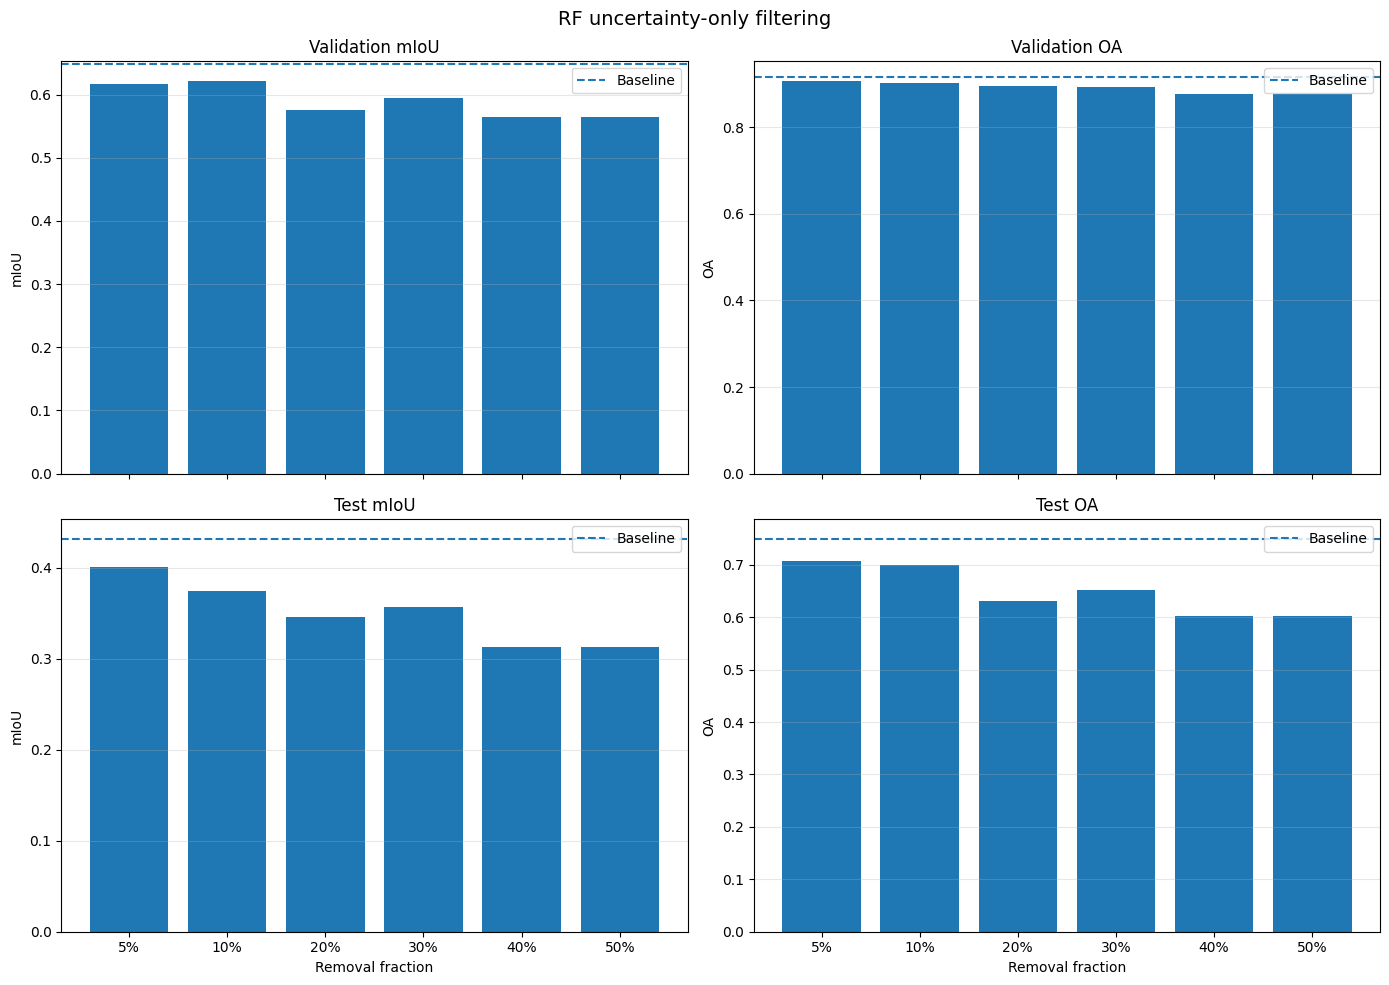

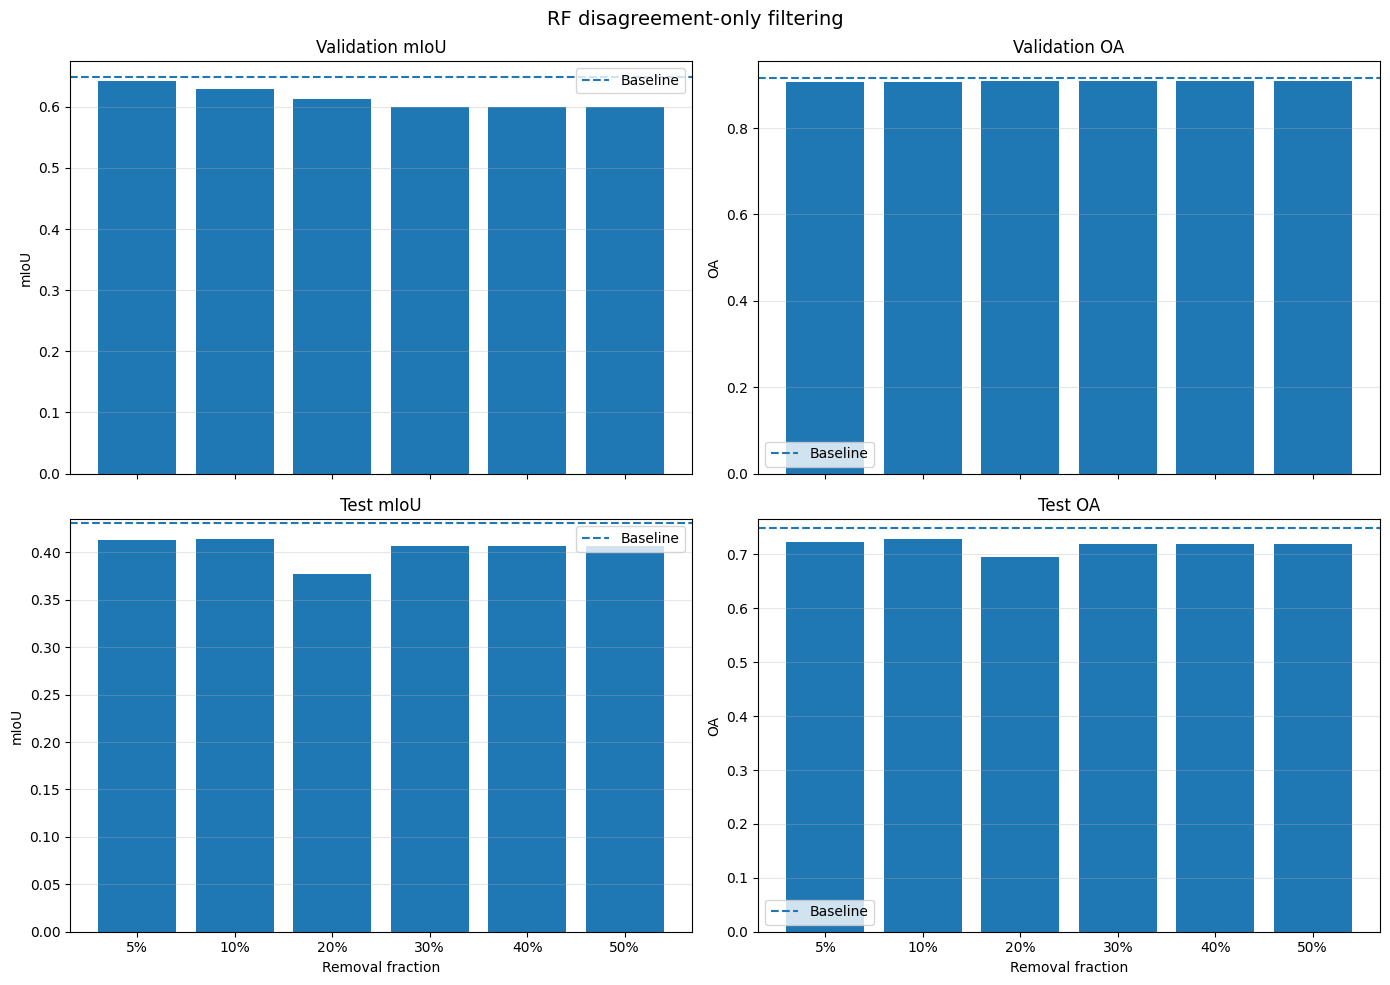

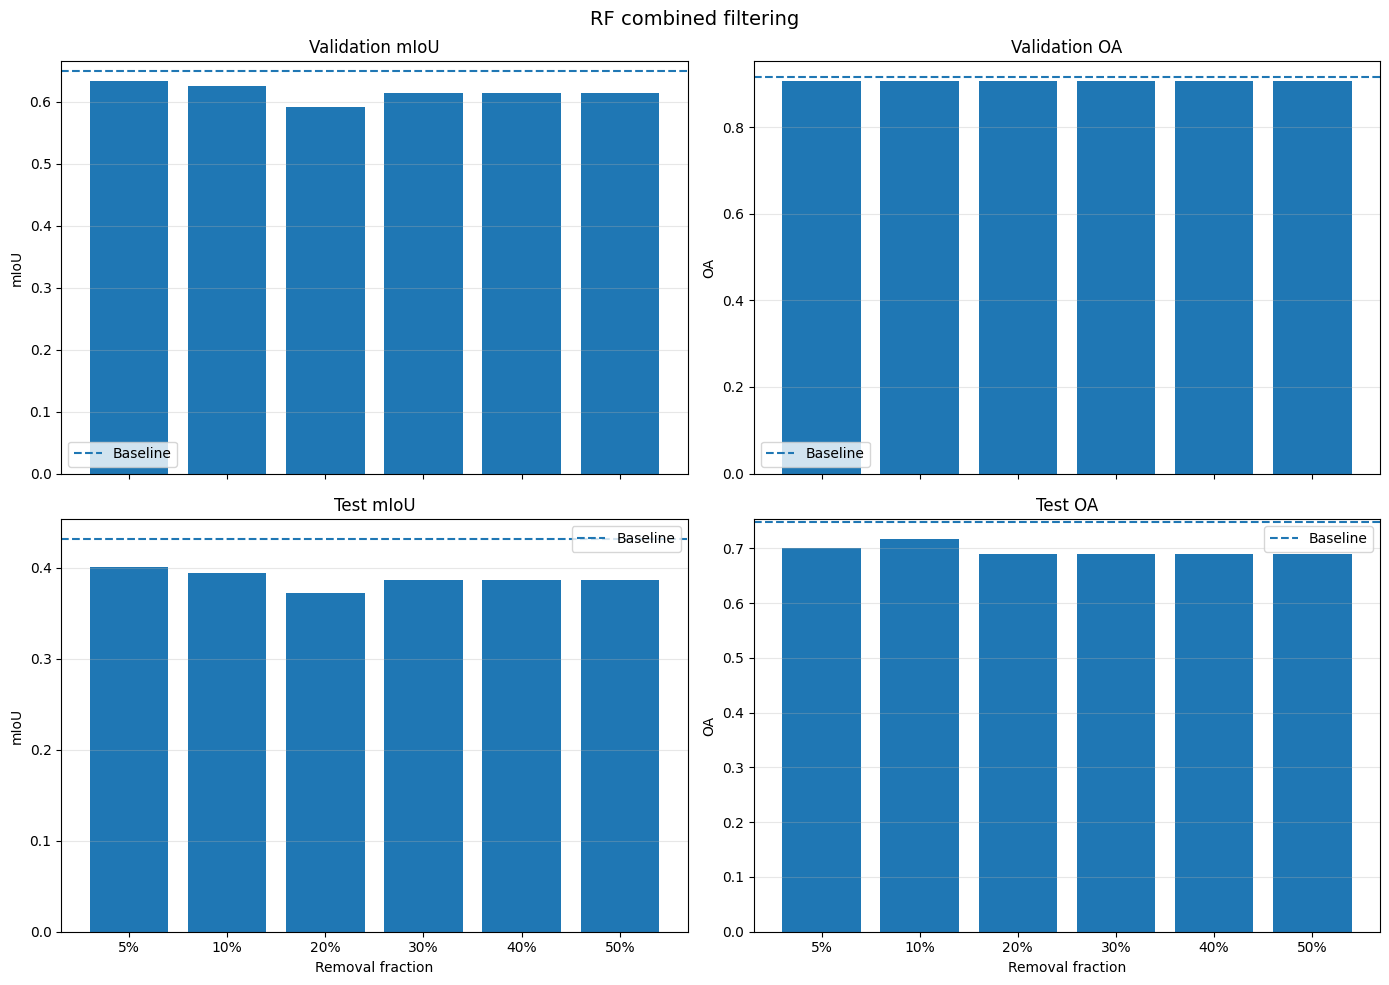

In [18]:
# Step 5.5 — Optional comparison plot (bar chart subplots: val + test)

def plot_summary_bars(summary_df: pd.DataFrame, title: str):
    d = summary_df[summary_df["exp_key"] != "baseline"].copy()
    d = d.sort_values("remove_frac").reset_index(drop=True)

    baseline = summary_df[summary_df["exp_key"] == "baseline"].iloc[0]

    x = np.arange(len(d))
    labels = [f"{int(r * 100)}%" for r in d["remove_frac"]]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    # ---- VAL mIoU ----
    axes[0, 0].bar(x, d["val_miou_mean"].to_numpy())
    axes[0, 0].axhline(float(baseline["val_miou_mean"]), linestyle="--", label="Baseline")
    axes[0, 0].set_title("Validation mIoU")
    axes[0, 0].set_ylabel("mIoU")
    axes[0, 0].grid(True, axis="y", alpha=0.3)
    axes[0, 0].legend()

    # ---- VAL OA ----
    axes[0, 1].bar(x, d["val_oa_mean"].to_numpy())
    axes[0, 1].axhline(float(baseline["val_oa_mean"]), linestyle="--", label="Baseline")
    axes[0, 1].set_title("Validation OA")
    axes[0, 1].set_ylabel("OA")
    axes[0, 1].grid(True, axis="y", alpha=0.3)
    axes[0, 1].legend()

    # ---- TEST mIoU ----
    axes[1, 0].bar(x, d["test_miou_mean"].to_numpy())
    axes[1, 0].axhline(float(baseline["test_miou_mean"]), linestyle="--", label="Baseline")
    axes[1, 0].set_title("Test mIoU")
    axes[1, 0].set_xlabel("Removal fraction")
    axes[1, 0].set_ylabel("mIoU")
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(labels)
    axes[1, 0].grid(True, axis="y", alpha=0.3)
    axes[1, 0].legend()

    # ---- TEST OA ----
    axes[1, 1].bar(x, d["test_oa_mean"].to_numpy())
    axes[1, 1].axhline(float(baseline["test_oa_mean"]), linestyle="--", label="Baseline")
    axes[1, 1].set_title("Test OA")
    axes[1, 1].set_xlabel("Removal fraction")
    axes[1, 1].set_ylabel("OA")
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(labels)
    axes[1, 1].grid(True, axis="y", alpha=0.3)
    axes[1, 1].legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_summary_bars(summary_unc, "RF uncertainty-only filtering")
plot_summary_bars(summary_dis, "RF disagreement-only filtering")
plot_summary_bars(summary_combo, "RF combined filtering")

## Cell 19 — Weighted RF table builder + score-matched weighting utilities + weighted RF runner

In [19]:
# Step 6.1 — Weighted RF table builder + score-matched weighting utilities + weighted RF runner

def build_rf_table_from_patches_weighted(
    split_name: str,
    img_path: str,
    lbl_path: str,
    patches: Sequence[PatchSpec],
    train_mean: np.ndarray,
    train_std: np.ndarray,
    nodata_value: int,
    ignore_index: int,
    max_pixels_total: int,
    max_pixels_per_patch: int,
    seed: int,
    patch_weights: Optional[np.ndarray] = None,
):
    """
    Same as build_rf_table_from_patches, but also returns a sample_weight vector
    aligned with each sampled pixel row.
    """
    rng = np.random.default_rng(seed)
    patch_order = np.arange(len(patches))
    rng.shuffle(patch_order)

    rows_X = []
    rows_y = []
    rows_w = []
    rows_meta = []
    feat_names_final = None
    total = 0

    for idx in patch_order:
        p = patches[int(idx)]

        Xp, yp, feat_names = extract_pixel_rows_from_patch(
            img_path=img_path,
            lbl_path=lbl_path,
            p=p,
            train_mean=train_mean,
            train_std=train_std,
            nodata_value=nodata_value,
            ignore_index=ignore_index,
            max_pixels_per_patch=max_pixels_per_patch,
            rng=rng,
        )

        if Xp is None:
            continue

        remaining = max_pixels_total - total
        if remaining <= 0:
            break

        if len(yp) > remaining:
            choose = rng.choice(len(yp), size=remaining, replace=False)
            Xp = Xp[choose]
            yp = yp[choose]

        rows_X.append(Xp)
        rows_y.append(yp)

        if patch_weights is None:
            wp = np.ones(len(yp), dtype=np.float32)
        else:
            wp = np.full(len(yp), float(patch_weights[int(idx)]), dtype=np.float32)
        rows_w.append(wp)

        rows_meta.append(pd.DataFrame([{
            "split": split_name,
            "patch_idx": int(idx),
            "row_off": int(p.row_off),
            "col_off": int(p.col_off),
            "n_pixels_used": int(len(yp)),
            "patch_weight": float(np.mean(wp)),
        }]))

        feat_names_final = feat_names
        total += len(yp)

        if total >= max_pixels_total:
            break

    X = np.vstack(rows_X).astype(np.float32) if rows_X else np.empty((0, 0), dtype=np.float32)
    y = np.concatenate(rows_y).astype(np.int64) if rows_y else np.empty((0,), dtype=np.int64)
    sample_weight = np.concatenate(rows_w).astype(np.float32) if rows_w else np.empty((0,), dtype=np.float32)
    meta_df = pd.concat(rows_meta, ignore_index=True) if rows_meta else pd.DataFrame()

    return X, y, sample_weight, meta_df, feat_names_final


def minmax_scale_series(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    s_min = float(s.min())
    s_max = float(s.max())
    if np.isclose(s_max, s_min):
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - s_min) / (s_max - s_min)


def build_patch_weights_uncertainty_only(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    target_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Downweight only selected uncertainty-target patches.
    Weight rule:
        w_i = max(w_min, 1 - scaled_entropy_i)
    Non-target patches get weight 1.0.
    """
    w = np.ones(n_patches, dtype=np.float32)
    w_min = float(w_min)

    df = scores_df_train.copy()
    df["entropy_scaled"] = minmax_scale_series(df["entropy_mean"])

    for r in df[["idx", "entropy_scaled"]].itertuples(index=False):
        i = int(r.idx)
        if i not in target_idx_set:
            continue
        score = float(r.entropy_scaled)
        score = min(1.0, max(0.0, score))
        w[i] = max(w_min, 1.0 - score)

    return w


def build_patch_weights_disagreement_only(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    target_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Downweight only selected disagreement-target patches.
    Weight rule:
        w_i = max(w_min, 1 - disagree_frac_i)
    Non-target patches get weight 1.0.
    """
    w = np.ones(n_patches, dtype=np.float32)
    w_min = float(w_min)

    df = scores_df_train.copy()

    for r in df[["idx", "disagree_frac"]].itertuples(index=False):
        i = int(r.idx)
        if i not in target_idx_set:
            continue
        score = float(r.disagree_frac)
        score = min(1.0, max(0.0, score))
        w[i] = max(w_min, 1.0 - score)

    return w


def build_patch_weights_combined(
    scores_df_train: pd.DataFrame,
    n_patches: int,
    target_idx_set: set,
    w_min: float,
) -> np.ndarray:
    """
    Downweight only selected combined-target patches.
    Combined score:
        combined_score = 0.5 * scaled_entropy + 0.5 * disagree_frac
        w_i = max(w_min, 1 - combined_score)
    Non-target patches get weight 1.0.
    """
    w = np.ones(n_patches, dtype=np.float32)
    w_min = float(w_min)

    df = scores_df_train.copy()
    df["entropy_scaled"] = minmax_scale_series(df["entropy_mean"])
    df["combined_score"] = 0.5 * df["entropy_scaled"] + 0.5 * df["disagree_frac"]

    for r in df[["idx", "combined_score"]].itertuples(index=False):
        i = int(r.idx)
        if i not in target_idx_set:
            continue
        score = float(r.combined_score)
        score = min(1.0, max(0.0, score))
        w[i] = max(w_min, 1.0 - score)

    return w


def run_one_strategy_weight_rf(strategy: dict, seed_run: int) -> dict:
    """
    strategy examples:
      {"name": "baseline_seed_42", "type": "baseline"}
      {"name": "unc_weight_wmin_0p3_seed_42", "type": "weight", "w_min": 0.3, "target_name": "uncertainty"}
    """
    seed_everything(seed_run)

    run_dir = split_dir / "rf_weight_runs" / strategy["name"]
    run_dir.mkdir(parents=True, exist_ok=True)

    target_name = strategy.get("target_name", "none")

    if strategy["type"] == "weight":
        w_min = float(strategy["w_min"])
        target_idx_set = set(strategy["target_ids"])

        if target_name == "uncertainty":
            patch_weights = build_patch_weights_uncertainty_only(
                scores_df_train=scores_train_clean,
                n_patches=len(train_patches),
                target_idx_set=target_idx_set,
                w_min=w_min,
            )
        elif target_name == "disagreement":
            patch_weights = build_patch_weights_disagreement_only(
                scores_df_train=scores_train_clean,
                n_patches=len(train_patches),
                target_idx_set=target_idx_set,
                w_min=w_min,
            )
        elif target_name == "combined":
            patch_weights = build_patch_weights_combined(
                scores_df_train=scores_train_clean,
                n_patches=len(train_patches),
                target_idx_set=target_idx_set,
                w_min=w_min,
            )
        else:
            raise ValueError(f"Unknown target_name: {target_name}")

        mean_target_weight = float(patch_weights[list(target_idx_set)].mean()) if len(target_idx_set) > 0 else np.nan
        min_target_weight = float(patch_weights[list(target_idx_set)].min()) if len(target_idx_set) > 0 else np.nan
        max_target_weight = float(patch_weights[list(target_idx_set)].max()) if len(target_idx_set) > 0 else np.nan
        n_target_available = int(len(target_idx_set))
    else:
        w_min = np.nan
        patch_weights = None
        mean_target_weight = 1.0
        min_target_weight = 1.0
        max_target_weight = 1.0
        n_target_available = 0

    # ---- TRAIN weighted / baseline ----
    X_train_run, y_train_run, sw_train_run, meta_train_run, feat_names_run = build_rf_table_from_patches_weighted(
        split_name="train",
        img_path=img_path,
        lbl_path=lbl_path,
        patches=train_patches,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        max_pixels_total=int(cfg["max_train_pixels_total"]),
        max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
        seed=int(seed_run),
        patch_weights=patch_weights,
    )

    # ---- VAL / TEST unchanged ----
    X_val_run, y_val_run, _, meta_val_run, _ = build_rf_table_from_patches_weighted(
        split_name="val",
        img_path=img_path,
        lbl_path=lbl_path,
        patches=val_patches,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        max_pixels_total=int(cfg["max_val_pixels_total"]),
        max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
        seed=int(seed_run) + 1,
        patch_weights=None,
    )

    X_test_run, y_test_run, _, meta_test_run, _ = build_rf_table_from_patches_weighted(
        split_name="test",
        img_path=img_path,
        lbl_path=lbl_path,
        patches=test_patches,
        train_mean=train_mean,
        train_std=train_std,
        nodata_value=cfg["nodata_value"],
        ignore_index=cfg["ignore_index"],
        max_pixels_total=int(cfg["max_test_pixels_total"]),
        max_pixels_per_patch=int(cfg["max_pixels_per_patch"]),
        seed=int(seed_run) + 2,
        patch_weights=None,
    )

    params_run = dict(RF_TUNED_PARAMS)
    params_run["random_state"] = int(seed_run)

    t0 = time.time()
    model_run = RandomForestClassifier(**params_run)

    if strategy["type"] == "weight":
        model_run.fit(X_train_run, y_train_run, sample_weight=sw_train_run)
    else:
        model_run.fit(X_train_run, y_train_run)

    train_time_sec = time.time() - t0

    metrics = evaluate_rf_on_val_test(
        model=model_run,
        X_val=X_val_run, y_val=y_val_run,
        X_test=X_test_run, y_test=y_test_run,
        num_classes=cfg["num_classes"],
    )

    joblib.dump(model_run, run_dir / "rf_model.joblib")
    meta_train_run.to_csv(run_dir / "rf_table_meta_train.csv", index=False)
    meta_val_run.to_csv(run_dir / "rf_table_meta_val.csv", index=False)
    meta_test_run.to_csv(run_dir / "rf_table_meta_test.csv", index=False)

    summary = {
        "strategy": strategy["name"],
        "type": strategy["type"],
        "target_name": target_name,
        "seed": int(seed_run),
        "w_min": float(w_min) if np.isfinite(w_min) else np.nan,
        "n_train_patches_used": int(len(train_patches)),
        "n_target_available": int(n_target_available),
        "mean_target_weight": float(mean_target_weight),
        "min_target_weight": float(min_target_weight),
        "max_target_weight": float(max_target_weight),
        "train_time_sec": float(train_time_sec),
        "val_macro_iou": float(metrics["val_macro_iou"]),
        "val_oa": float(metrics["val_oa"]),
        "test_macro_iou": float(metrics["test_macro_iou"]),
        "test_oa": float(metrics["test_oa"]),
        "run_dir": str(run_dir),
    }

    with open(run_dir / "eval_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(
        f"[{strategy['name']}] "
        f"val_mIoU={summary['val_macro_iou']:.4f} | "
        f"test_mIoU={summary['test_macro_iou']:.4f}"
    )

    return summary

print("Score-matched weighted RF runner ready.")

Score-matched weighted RF runner ready.


## Cell 20 — Define target patch sets for the three weighting families

In [20]:
# Step 6.2 — Define target patch sets for weighting

unc_target_ids = set(
    scores_train_clean.loc[
        scores_train_clean["entropy_mean"] >= float(entropy_threshold_q60),
        "idx"
    ].astype(int).tolist()
)

dis_target_ids = set(
    scores_train_clean.loc[
        scores_train_clean["disagree_frac"] >= float(disagreement_threshold_q75),
        "idx"
    ].astype(int).tolist()
)

combo_target_ids = set(
    scores_train_clean.loc[
        (scores_train_clean["entropy_mean"] >= float(entropy_threshold_q60)) &
        (scores_train_clean["disagree_frac"] >= float(disagreement_threshold_q75)),
        "idx"
    ].astype(int).tolist()
)

print("Target counts")
print("uncertainty-only :", len(unc_target_ids))
print("disagreement-only:", len(dis_target_ids))
print("combined         :", len(combo_target_ids))

Target counts
uncertainty-only : 699
disagreement-only: 566
combined         : 421


## Cell 21 — Summary + Pareto helpers for weighting sweeps

In [21]:
# Step 6.3 — Summary + Pareto helpers for weighting sweeps

def summarise_weight_runs(df_runs: pd.DataFrame, out_csv: Path):
    summary = (
        df_runs
        .groupby(["exp_key", "w_min_key"], as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_target_available=("n_target_available", "mean"),
            mean_target_weight=("mean_target_weight", "mean"),

            val_miou_mean=("val_macro_iou", "mean"),
            val_miou_std=("val_macro_iou", "std"),
            val_oa_mean=("val_oa", "mean"),
            val_oa_std=("val_oa", "std"),

            test_miou_mean=("test_macro_iou", "mean"),
            test_miou_std=("test_macro_iou", "std"),
            test_oa_mean=("test_oa", "mean"),
            test_oa_std=("test_oa", "std"),
        )
    )

    summary["val_miou_mean±std"] = summary.apply(
        lambda r: f"{r['val_miou_mean']:.4f} ± {r['val_miou_std']:.4f}", axis=1
    )
    summary["val_oa_mean±std"] = summary.apply(
        lambda r: f"{r['val_oa_mean']:.4f} ± {r['val_oa_std']:.4f}", axis=1
    )
    summary["test_miou_mean±std"] = summary.apply(
        lambda r: f"{r['test_miou_mean']:.4f} ± {r['test_miou_std']:.4f}", axis=1
    )
    summary["test_oa_mean±std"] = summary.apply(
        lambda r: f"{r['test_oa_mean']:.4f} ± {r['test_oa_std']:.4f}", axis=1
    )

    baseline_row = summary[summary["exp_key"] == "baseline"].iloc[0]
    baseline_test_miou = float(baseline_row["test_miou_mean"])
    baseline_test_oa = float(baseline_row["test_oa_mean"])

    summary["delta_test_miou_vs_baseline"] = summary["test_miou_mean"] - baseline_test_miou
    summary["delta_test_oa_vs_baseline"] = summary["test_oa_mean"] - baseline_test_oa

    summary["_w_sort"] = pd.to_numeric(summary["w_min_key"], errors="coerce").fillna(-1.0)
    summary = summary.sort_values(["_w_sort", "exp_key"]).drop(columns="_w_sort")

    summary.to_csv(out_csv, index=False)
    print("Saved summary:", out_csv)

    return summary


def pareto_efficient_maxmax(df: pd.DataFrame, miou_col: str, oa_col: str) -> pd.DataFrame:
    rows = df.copy().reset_index(drop=True)
    mi = rows[miou_col].to_numpy()
    oa = rows[oa_col].to_numpy()

    keep = np.ones(len(rows), dtype=bool)

    for i in range(len(rows)):
        if not keep[i]:
            continue
        dominates_i = (mi >= mi[i]) & (oa >= oa[i]) & ((mi > mi[i]) | (oa > oa[i]))
        dominates_i[i] = False
        if dominates_i.any():
            keep[i] = False

    return rows[keep].copy().reset_index(drop=True)


def select_best_pareto_vs_baseline(summary_df: pd.DataFrame):
    MI = "val_miou_mean"
    OA = "val_oa_mean"

    df_sum = summary_df.copy()
    df_pareto = pareto_efficient_maxmax(df_sum, MI, OA)

    target_miou = float(df_sum[MI].max())
    target_oa   = float(df_sum[OA].max())

    mi_range = float(df_sum[MI].max() - df_sum[MI].min()) or 1.0
    oa_range = float(df_sum[OA].max() - df_sum[OA].min()) or 1.0

    def dist_to_target(row):
        d_mi = (target_miou - float(row[MI])) / mi_range
        d_oa = (target_oa - float(row[OA])) / oa_range
        return float(np.sqrt(d_mi**2 + d_oa**2))

    df_pareto = df_pareto.copy()
    df_pareto["dist_to_target"] = df_pareto.apply(dist_to_target, axis=1)

    best_row = df_pareto.sort_values("dist_to_target", ascending=True).iloc[0]
    chosen_key = str(best_row["exp_key"])

    if chosen_key == "baseline":
        df_report = df_sum[df_sum["exp_key"] == "baseline"].copy()
    else:
        df_report = df_sum[df_sum["exp_key"].isin(["baseline", chosen_key])].copy()

    order = {"baseline": 0, chosen_key: 1}
    df_report["_ord"] = df_report["exp_key"].map(order).fillna(99).astype(int)
    df_report = df_report.sort_values("_ord").drop(columns="_ord")

    return df_pareto, best_row, df_report

print("Weighting summary + Pareto helpers ready.")

Weighting summary + Pareto helpers ready.


## Cell 22 — 10-seed w_min sweep: entropy-only weighting

In [22]:
# Step 6.4 — Entropy-only weighting sweep

SEEDS_WEIGHT = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
W_MIN_SWEEP = np.round(np.linspace(0.0, 1.0, 11), 1).tolist()

all_rows_unc_weight = []

EXPERIMENTS_UNC_WEIGHT = [{"key": "baseline", "type": "baseline", "w_min": None}]
for wmin in W_MIN_SWEEP:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_UNC_WEIGHT.append({
        "key": f"unc_weight_wmin_{tag}",
        "type": "weight",
        "w_min": float(wmin),
        "target_name": "uncertainty",
        "target_ids": sorted(list(unc_target_ids)),
    })

for exp in EXPERIMENTS_UNC_WEIGHT:
    for s in SEEDS_WEIGHT:
        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
                "target_name": "uncertainty",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight",
                "w_min": float(exp["w_min"]),
                "target_name": exp["target_name"],
                "target_ids": exp["target_ids"],
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_rf(strat, seed_run=s)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_unc_weight.append(res)

df_unc_weight = pd.DataFrame(all_rows_unc_weight)
df_unc_weight["w_min_key"] = df_unc_weight["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

unc_weight_raw_out = split_dir / "rf_uncertainty_only_weight_sweep_10seeds_raw.csv"
df_unc_weight.to_csv(unc_weight_raw_out, index=False)

print("Saved raw:", unc_weight_raw_out)
display(df_unc_weight.head())


Running: {'name': 'baseline_seed_42', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_42] val_mIoU=0.6984 | test_mIoU=0.4086

Running: {'name': 'baseline_seed_43', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_43] val_mIoU=0.6205 | test_mIoU=0.5521

Running: {'name': 'baseline_seed_44', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_44] val_mIoU=0.6503 | test_mIoU=0.3882

Running: {'name': 'baseline_seed_45', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_45] val_mIoU=0.6849 | test_mIoU=0.5083

Running: {'name': 'baseline_seed_46', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_46] val_mIoU=0.6742 | test_mIoU=0.4068

Running: {'name': 'baseline_seed_47', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_47] val_mIoU=0.6925 | test_mIoU=0.5288

Running: {'name': 'baseline_seed_48', 'type': 'baseline', 'target_name': 'uncertainty'}
[baseline_seed_48] val_mIoU=0.6846 | test_mIoU=0.4223

,strategy,type,target_name,seed,w_min,n_train_patches_used,n_target_available,mean_target_weight,min_target_weight,max_target_weight,train_time_sec,val_macro_iou,val_oa,test_macro_iou,test_oa,run_dir,exp_key,w_min_key
0,baseline_seed_42,baseline,uncertainty,42,NaN,2012,0,1.0,1.0,1.0,9.962326,0.698365,0.899525,0.408638,0.761475,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
1,baseline_seed_43,baseline,uncertainty,43,NaN,2012,0,1.0,1.0,1.0,9.478729,0.620499,0.909875,0.552115,0.807400,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
2,baseline_seed_44,baseline,uncertainty,44,NaN,2012,0,1.0,1.0,1.0,9.280262,0.650290,0.901425,0.388250,0.776625,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
3,baseline_seed_45,baseline,uncertainty,45,NaN,2012,0,1.0,1.0,1.0,9.348781,0.684934,0.913350,0.508254,0.806025,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
4,baseline_seed_46,baseline,uncertainty,46,NaN,2012,0,1.0,1.0,1.0,10.672795,0.674228,0.901825,0.406784,0.704275,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline


## Cell 23 — Summary + Pareto: entropy-only weighting

In [23]:
# Step 6.5 — Summary + Pareto for entropy-only weighting

summary_unc_weight = summarise_weight_runs(
    df_runs=df_unc_weight,
    out_csv=split_dir / "rf_uncertainty_only_weight_sweep_10seeds_summary.csv"
)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
df_pareto_unc_weight, best_unc_weight_row, report_unc_weight = select_best_pareto_vs_baseline(summary_unc_weight)

display(
    df_pareto_unc_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std"
    ]]
)

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_unc_weight_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std",
        "dist_to_target"
    ]]
)

print("=== Final comparison ===")
display(
    report_unc_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_oa_vs_baseline"
    ]]
)

Saved summary: ../../data/outputs/proposed/small_rf_p256_b2048/rf_uncertainty_only_weight_sweep_10seeds_summary.csv
=== Pareto-efficient settings (INCLUDING baseline) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std
0,baseline,baseline,10,0.6488 ± 0.0498,0.9155 ± 0.0150,0.4315 ± 0.0755,0.7489 ± 0.0518
1,unc_weight_wmin_0p0,0.0,10,0.6496 ± 0.0482,0.9151 ± 0.0151,0.4237 ± 0.0736,0.7407 ± 0.0490
2,unc_weight_wmin_0p4,0.4,10,0.6491 ± 0.0474,0.9152 ± 0.0151,0.4241 ± 0.0733,0.7412 ± 0.0481
3,unc_weight_wmin_0p6,0.6,10,0.6490 ± 0.0487,0.9153 ± 0.0149,0.4247 ± 0.0745,0.7406 ± 0.0490
4,unc_weight_wmin_1p0,1.0,10,0.6488 ± 0.0498,0.9155 ± 0.0150,0.4315 ± 0.0755,0.7489 ± 0.0518


=== Selected setting (baseline may win) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std,dist_to_target
0,baseline,baseline,10,0.6488 ± 0.0498,0.9155 ± 0.0150,0.4315 ± 0.0755,0.7489 ± 0.0518,0.391642


=== Final comparison ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std,delta_test_miou_vs_baseline,delta_test_oa_vs_baseline
0,baseline,baseline,10,0.6488 ± 0.0498,0.9155 ± 0.0150,0.4315 ± 0.0755,0.7489 ± 0.0518,0.0,0.0


## Cell 24 — 10-seed w_min sweep: disagreement-only weighting

In [24]:
# Step 6.6 — Disagreement-only weighting sweep

all_rows_dis_weight = []

EXPERIMENTS_DIS_WEIGHT = [{"key": "baseline", "type": "baseline", "w_min": None}]
for wmin in W_MIN_SWEEP:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_DIS_WEIGHT.append({
        "key": f"dis_weight_wmin_{tag}",
        "type": "weight",
        "w_min": float(wmin),
        "target_name": "disagreement",
        "target_ids": sorted(list(dis_target_ids)),
    })

for exp in EXPERIMENTS_DIS_WEIGHT:
    for s in SEEDS_WEIGHT:
        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
                "target_name": "disagreement",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight",
                "w_min": float(exp["w_min"]),
                "target_name": exp["target_name"],
                "target_ids": exp["target_ids"],
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_rf(strat, seed_run=s)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_dis_weight.append(res)

df_dis_weight = pd.DataFrame(all_rows_dis_weight)
df_dis_weight["w_min_key"] = df_dis_weight["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

dis_weight_raw_out = split_dir / "rf_disagreement_only_weight_sweep_10seeds_raw.csv"
df_dis_weight.to_csv(dis_weight_raw_out, index=False)

print("Saved raw:", dis_weight_raw_out)
display(df_dis_weight.head())


Running: {'name': 'baseline_seed_42', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_42] val_mIoU=0.6984 | test_mIoU=0.4086

Running: {'name': 'baseline_seed_43', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_43] val_mIoU=0.6205 | test_mIoU=0.5521

Running: {'name': 'baseline_seed_44', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_44] val_mIoU=0.6503 | test_mIoU=0.3882

Running: {'name': 'baseline_seed_45', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_45] val_mIoU=0.6849 | test_mIoU=0.5083

Running: {'name': 'baseline_seed_46', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_46] val_mIoU=0.6742 | test_mIoU=0.4068

Running: {'name': 'baseline_seed_47', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_47] val_mIoU=0.6925 | test_mIoU=0.5288

Running: {'name': 'baseline_seed_48', 'type': 'baseline', 'target_name': 'disagreement'}
[baseline_seed_48] val_mIoU=0.6846 | test_mIoU

,strategy,type,target_name,seed,w_min,n_train_patches_used,n_target_available,mean_target_weight,min_target_weight,max_target_weight,train_time_sec,val_macro_iou,val_oa,test_macro_iou,test_oa,run_dir,exp_key,w_min_key
0,baseline_seed_42,baseline,disagreement,42,NaN,2012,0,1.0,1.0,1.0,9.170417,0.698365,0.899525,0.408638,0.761475,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
1,baseline_seed_43,baseline,disagreement,43,NaN,2012,0,1.0,1.0,1.0,9.207837,0.620499,0.909875,0.552115,0.807400,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
2,baseline_seed_44,baseline,disagreement,44,NaN,2012,0,1.0,1.0,1.0,8.816165,0.650290,0.901425,0.388250,0.776625,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
3,baseline_seed_45,baseline,disagreement,45,NaN,2012,0,1.0,1.0,1.0,9.070553,0.684934,0.913350,0.508254,0.806025,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
4,baseline_seed_46,baseline,disagreement,46,NaN,2012,0,1.0,1.0,1.0,9.300196,0.674228,0.901825,0.406784,0.704275,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline


## Cell 25 — Summary + Pareto: disagreement-only weighting

In [25]:
# Step 6.7 — Summary + Pareto for disagreement-only weighting

summary_dis_weight = summarise_weight_runs(
    df_runs=df_dis_weight,
    out_csv=split_dir / "rf_disagreement_only_weight_sweep_10seeds_summary.csv"
)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
df_pareto_dis_weight, best_dis_weight_row, report_dis_weight = select_best_pareto_vs_baseline(summary_dis_weight)

display(
    df_pareto_dis_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std"
    ]]
)

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_dis_weight_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std",
        "dist_to_target"
    ]]
)

print("=== Final comparison ===")
display(
    report_dis_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_oa_vs_baseline"
    ]]
)

Saved summary: ../../data/outputs/proposed/small_rf_p256_b2048/rf_disagreement_only_weight_sweep_10seeds_summary.csv
=== Pareto-efficient settings (INCLUDING baseline) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std
0,dis_weight_wmin_0p1,0.1,10,0.6490 ± 0.0466,0.9167 ± 0.0145,0.4276 ± 0.0746,0.7443 ± 0.0488
1,dis_weight_wmin_0p6,0.6,10,0.6495 ± 0.0471,0.9166 ± 0.0146,0.4318 ± 0.0752,0.7488 ± 0.0505
2,dis_weight_wmin_0p9,0.9,10,0.6496 ± 0.0481,0.9161 ± 0.0145,0.4318 ± 0.0751,0.7497 ± 0.0515


=== Selected setting (baseline may win) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std,dist_to_target
1,dis_weight_wmin_0p6,0.6,10,0.6495 ± 0.0471,0.9166 ± 0.0146,0.4318 ± 0.0752,0.7488 ± 0.0505,0.081388


=== Final comparison ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std,delta_test_miou_vs_baseline,delta_test_oa_vs_baseline
0,baseline,baseline,10,0.6488 ± 0.0498,0.9155 ± 0.0150,0.4315 ± 0.0755,0.7489 ± 0.0518,0.000000,0.000000
7,dis_weight_wmin_0p6,0.6,10,0.6495 ± 0.0471,0.9166 ± 0.0146,0.4318 ± 0.0752,0.7488 ± 0.0505,0.000354,-0.000157


## Cell 26 — 10-seed w_min sweep: combined weighting

In [26]:
# Step 6.8 — Combined weighting sweep

all_rows_combo_weight = []

EXPERIMENTS_COMBO_WEIGHT = [{"key": "baseline", "type": "baseline", "w_min": None}]
for wmin in W_MIN_SWEEP:
    tag = str(wmin).replace(".", "p")
    EXPERIMENTS_COMBO_WEIGHT.append({
        "key": f"combo_weight_wmin_{tag}",
        "type": "weight",
        "w_min": float(wmin),
        "target_name": "combined",
        "target_ids": sorted(list(combo_target_ids)),
    })

for exp in EXPERIMENTS_COMBO_WEIGHT:
    for s in SEEDS_WEIGHT:
        if exp["type"] == "baseline":
            strat = {
                "name": f"baseline_seed_{s}",
                "type": "baseline",
                "target_name": "combined",
            }
        else:
            strat = {
                "name": f"{exp['key']}_seed_{s}",
                "type": "weight",
                "w_min": float(exp["w_min"]),
                "target_name": exp["target_name"],
                "target_ids": exp["target_ids"],
            }

        print("\n==============================")
        print("Running:", strat)
        print("==============================")

        res = run_one_strategy_weight_rf(strat, seed_run=s)
        res["exp_key"] = exp["key"]
        res["w_min"] = float(exp["w_min"]) if exp["w_min"] is not None else np.nan
        all_rows_combo_weight.append(res)

df_combo_weight = pd.DataFrame(all_rows_combo_weight)
df_combo_weight["w_min_key"] = df_combo_weight["w_min"].apply(
    lambda x: "baseline" if pd.isna(x) else f"{float(x):.1f}"
)

combo_weight_raw_out = split_dir / "rf_combined_weight_sweep_10seeds_raw.csv"
df_combo_weight.to_csv(combo_weight_raw_out, index=False)

print("Saved raw:", combo_weight_raw_out)
display(df_combo_weight.head())


Running: {'name': 'baseline_seed_42', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_42] val_mIoU=0.6984 | test_mIoU=0.4086

Running: {'name': 'baseline_seed_43', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_43] val_mIoU=0.6205 | test_mIoU=0.5521

Running: {'name': 'baseline_seed_44', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_44] val_mIoU=0.6503 | test_mIoU=0.3882

Running: {'name': 'baseline_seed_45', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_45] val_mIoU=0.6849 | test_mIoU=0.5083

Running: {'name': 'baseline_seed_46', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_46] val_mIoU=0.6742 | test_mIoU=0.4068

Running: {'name': 'baseline_seed_47', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_47] val_mIoU=0.6925 | test_mIoU=0.5288

Running: {'name': 'baseline_seed_48', 'type': 'baseline', 'target_name': 'combined'}
[baseline_seed_48] val_mIoU=0.6846 | test_mIoU=0.4223

Running: {'name': '

,strategy,type,target_name,seed,w_min,n_train_patches_used,n_target_available,mean_target_weight,min_target_weight,max_target_weight,train_time_sec,val_macro_iou,val_oa,test_macro_iou,test_oa,run_dir,exp_key,w_min_key
0,baseline_seed_42,baseline,combined,42,NaN,2012,0,1.0,1.0,1.0,9.036596,0.698365,0.899525,0.408638,0.761475,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
1,baseline_seed_43,baseline,combined,43,NaN,2012,0,1.0,1.0,1.0,9.026351,0.620499,0.909875,0.552115,0.807400,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
2,baseline_seed_44,baseline,combined,44,NaN,2012,0,1.0,1.0,1.0,8.849132,0.650290,0.901425,0.388250,0.776625,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
3,baseline_seed_45,baseline,combined,45,NaN,2012,0,1.0,1.0,1.0,8.945615,0.684934,0.913350,0.508254,0.806025,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline
4,baseline_seed_46,baseline,combined,46,NaN,2012,0,1.0,1.0,1.0,9.410431,0.674228,0.901825,0.406784,0.704275,../../data/outputs/proposed/small_rf_p256_b204...,baseline,baseline


## Cell 27 — Summary + Pareto: combined weighting

In [27]:
# Step 6.9 — Summary + Pareto for combined weighting

summary_combo_weight = summarise_weight_runs(
    df_runs=df_combo_weight,
    out_csv=split_dir / "rf_combined_weight_sweep_10seeds_summary.csv"
)

print("=== Pareto-efficient settings (INCLUDING baseline) ===")
df_pareto_combo_weight, best_combo_weight_row, report_combo_weight = select_best_pareto_vs_baseline(summary_combo_weight)

display(
    df_pareto_combo_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std"
    ]]
)

print("=== Selected setting (baseline may win) ===")
display(
    pd.DataFrame([best_combo_weight_row])[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std",
        "dist_to_target"
    ]]
)

print("=== Final comparison ===")
display(
    report_combo_weight[[
        "exp_key", "w_min_key", "n_runs",
        "val_miou_mean±std", "val_oa_mean±std",
        "test_miou_mean±std", "test_oa_mean±std",
        "delta_test_miou_vs_baseline", "delta_test_oa_vs_baseline"
    ]]
)

Saved summary: ../../data/outputs/proposed/small_rf_p256_b2048/rf_combined_weight_sweep_10seeds_summary.csv
=== Pareto-efficient settings (INCLUDING baseline) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std
0,combo_weight_wmin_0p3,0.3,10,0.6509 ± 0.0475,0.9163 ± 0.0144,0.4287 ± 0.0749,0.7454 ± 0.0503


=== Selected setting (baseline may win) ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std,dist_to_target
0,combo_weight_wmin_0p3,0.3,10,0.6509 ± 0.0475,0.9163 ± 0.0144,0.4287 ± 0.0749,0.7454 ± 0.0503,0.0


=== Final comparison ===


,exp_key,w_min_key,n_runs,val_miou_mean±std,val_oa_mean±std,test_miou_mean±std,test_oa_mean±std,delta_test_miou_vs_baseline,delta_test_oa_vs_baseline
0,baseline,baseline,10,0.6488 ± 0.0498,0.9155 ± 0.0150,0.4315 ± 0.0755,0.7489 ± 0.0518,0.000000,0.000000
4,combo_weight_wmin_0p3,0.3,10,0.6509 ± 0.0475,0.9163 ± 0.0144,0.4287 ± 0.0749,0.7454 ± 0.0503,-0.002724,-0.003578


## Optional plotting cell for the weighting sweeps

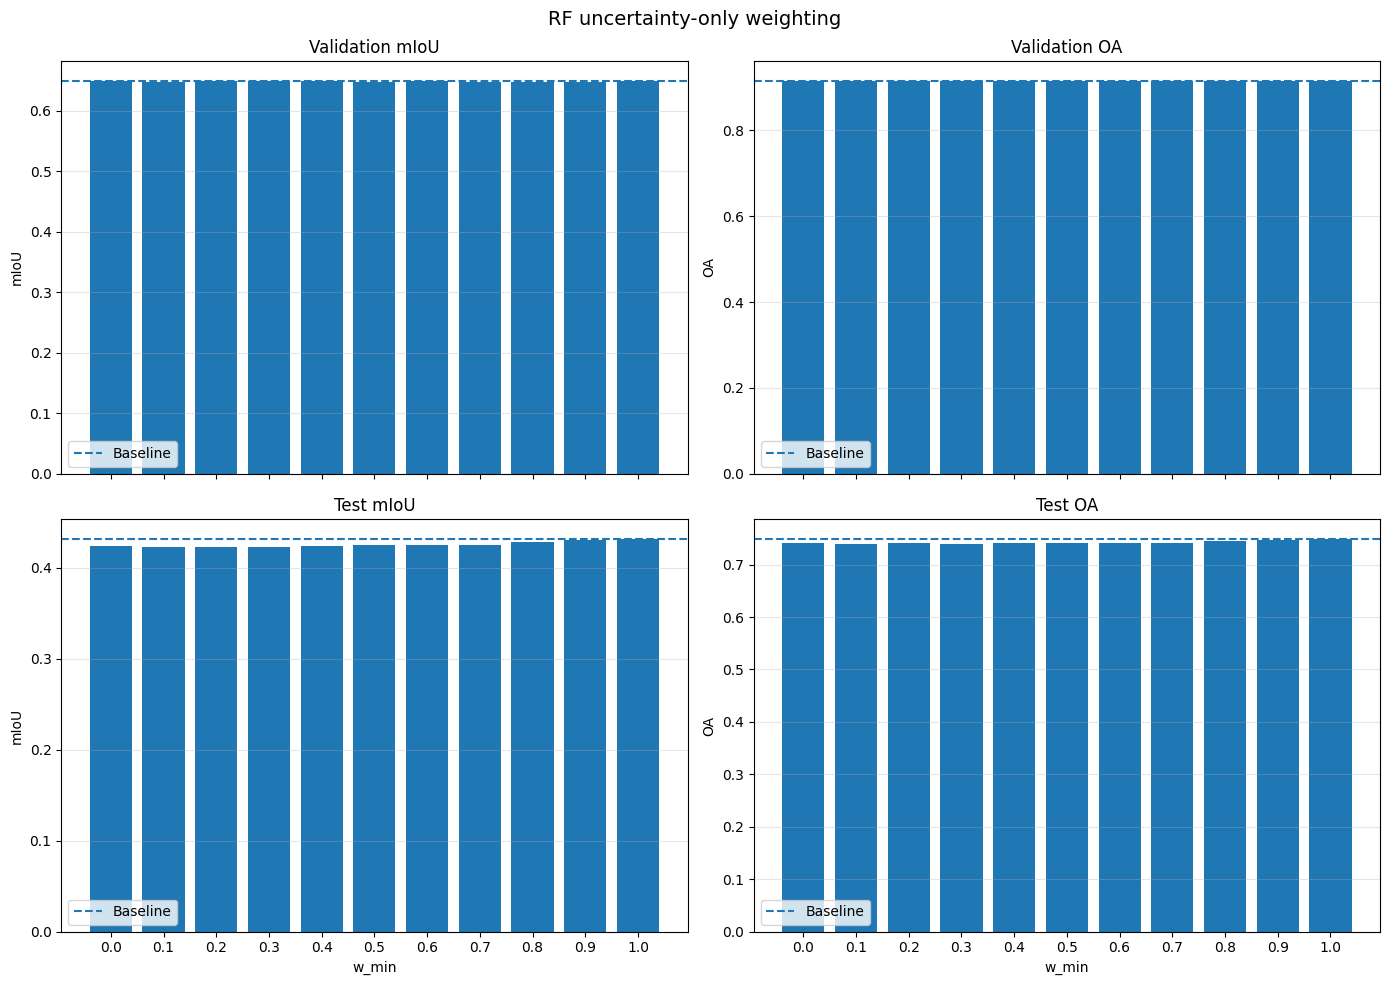

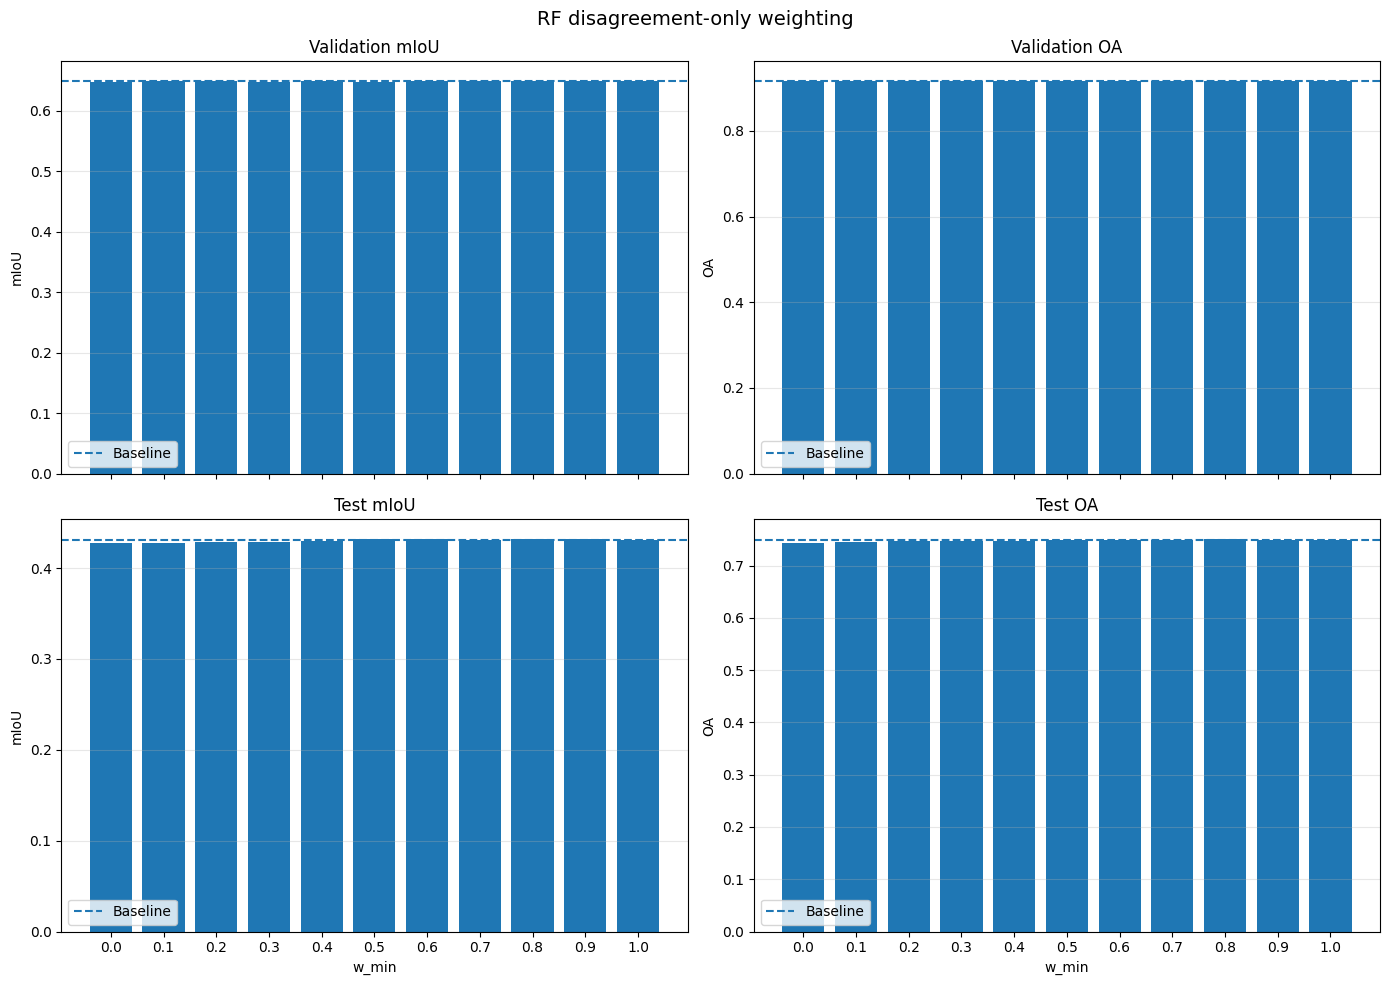

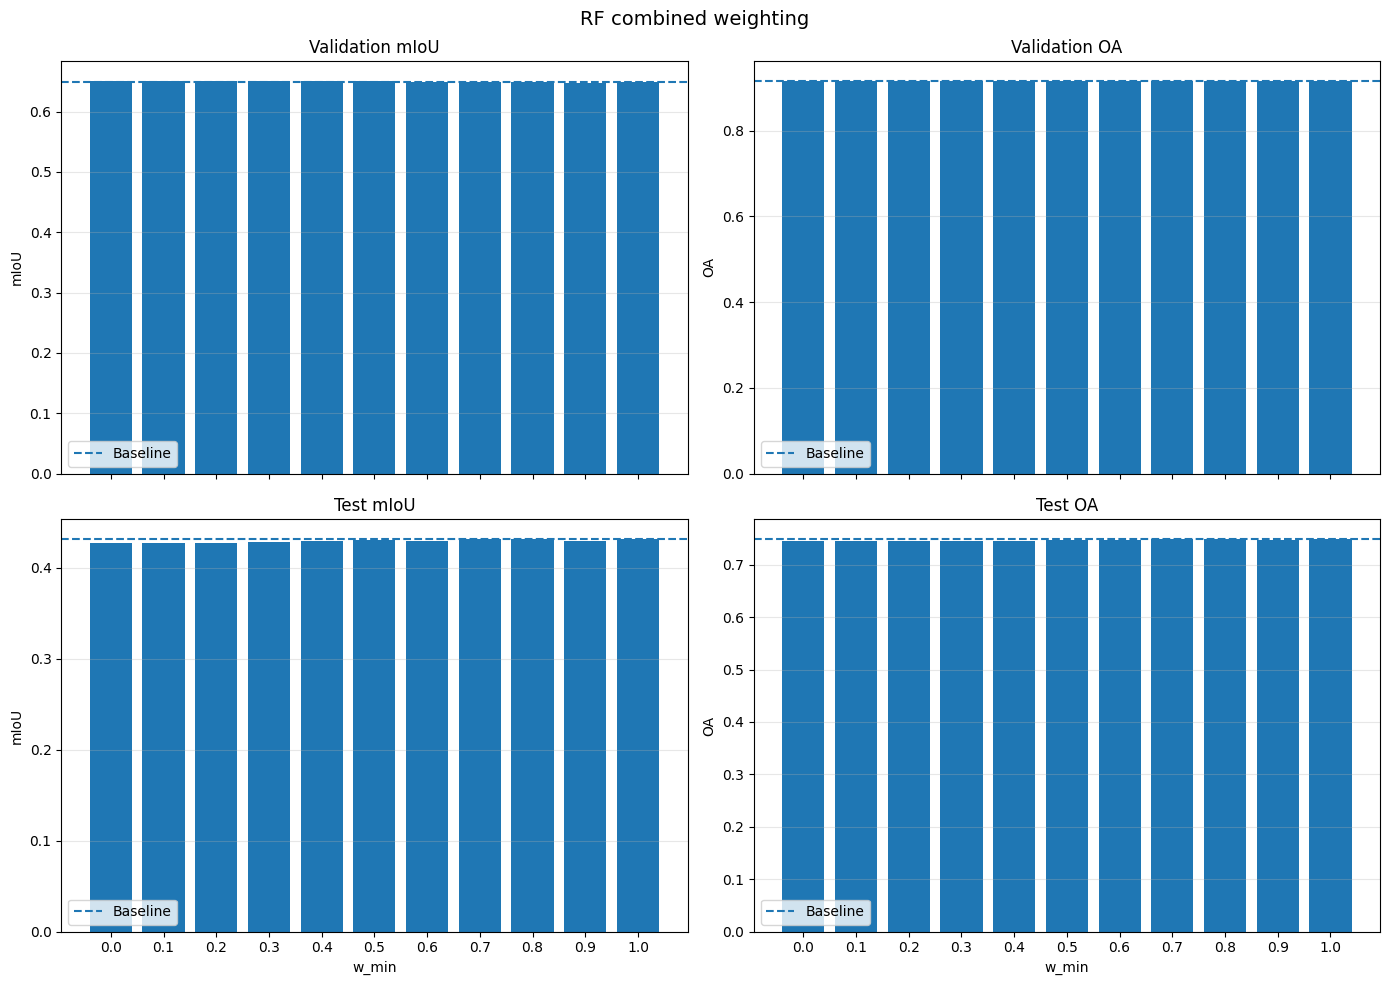

In [28]:
# Step 6.10 — Optional comparison plot for weighting sweeps

def plot_weight_summary_bars(summary_df: pd.DataFrame, title: str):
    d = summary_df[summary_df["exp_key"] != "baseline"].copy()
    d["w_min_num"] = pd.to_numeric(d["w_min_key"], errors="coerce")
    d = d.sort_values("w_min_num").reset_index(drop=True)

    baseline = summary_df[summary_df["exp_key"] == "baseline"].iloc[0]

    x = np.arange(len(d))
    labels = [f"{w:.1f}" for w in d["w_min_num"]]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    axes[0, 0].bar(x, d["val_miou_mean"].to_numpy())
    axes[0, 0].axhline(float(baseline["val_miou_mean"]), linestyle="--", label="Baseline")
    axes[0, 0].set_title("Validation mIoU")
    axes[0, 0].set_ylabel("mIoU")
    axes[0, 0].grid(True, axis="y", alpha=0.3)
    axes[0, 0].legend()

    axes[0, 1].bar(x, d["val_oa_mean"].to_numpy())
    axes[0, 1].axhline(float(baseline["val_oa_mean"]), linestyle="--", label="Baseline")
    axes[0, 1].set_title("Validation OA")
    axes[0, 1].set_ylabel("OA")
    axes[0, 1].grid(True, axis="y", alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].bar(x, d["test_miou_mean"].to_numpy())
    axes[1, 0].axhline(float(baseline["test_miou_mean"]), linestyle="--", label="Baseline")
    axes[1, 0].set_title("Test mIoU")
    axes[1, 0].set_xlabel("w_min")
    axes[1, 0].set_ylabel("mIoU")
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(labels)
    axes[1, 0].grid(True, axis="y", alpha=0.3)
    axes[1, 0].legend()

    axes[1, 1].bar(x, d["test_oa_mean"].to_numpy())
    axes[1, 1].axhline(float(baseline["test_oa_mean"]), linestyle="--", label="Baseline")
    axes[1, 1].set_title("Test OA")
    axes[1, 1].set_xlabel("w_min")
    axes[1, 1].set_ylabel("OA")
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(labels)
    axes[1, 1].grid(True, axis="y", alpha=0.3)
    axes[1, 1].legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_weight_summary_bars(summary_unc_weight, "RF uncertainty-only weighting")
plot_weight_summary_bars(summary_dis_weight, "RF disagreement-only weighting")
plot_weight_summary_bars(summary_combo_weight, "RF combined weighting")